# Notebook 2: Foreground removal and effects on power spectrum

Let us follow on the previous on the notebook, and add foregrounds to the map:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean

In [2]:
# this is for saving plots?
import os

# this is for the multiprocessing but works with Jupyter notebooks
from joblib import Parallel, delayed

# this is to create a progress bar when running code 
from tqdm import tqdm
import time

In [3]:
# copy and paste in function which makes saving files easier
def save_project_plot(fig, week_number, filename):
    """
    Saves a matplotlib figure to a specific week's folder.
    Example: week_number=1 saves to .../outputs/week1/
    """
    # 1. Define the base path
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    
    # 2. Create the week-specific folder name
    week_folder = f"week{week_number}"
    
    # 3. Combine them into a full path
    target_dir = os.path.join(base_path, week_folder)
    
    # 4. Create the directory if it doesn't exist yet
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created new directory: {target_dir}")
    
    # 5. Define the final file path
    save_path = os.path.join(target_dir, filename)
    
    # 6. Save the figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Successfully saved: {save_path}")

In [4]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 16,          # Base font size
    'axes.labelsize': 20,     # RA and Dec label size
    'axes.titlesize': 22,     # Map title size
    'xtick.labelsize': 16,    # X-axis tick size
    'ytick.labelsize': 16,    # Y-axis tick size
    'legend.fontsize': 18,    # Legend size
})

In [5]:
mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    ra_range=(334, 357),
    dec_range=(-35, -26.5),
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='pysm',
)
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)


Foreground simulation takes a bit longer. If you prefer you can save the foreground map and load it later, as it will not change as long as your survey area and frequency do not change.

Let us look at the maps:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/hydrogen_map_wo_foreground.pdf


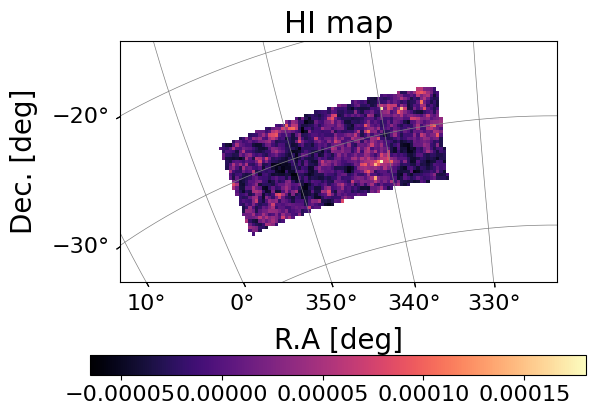

In [6]:
plot_map(hi_map,mock.wproj,W=mock.W_HI,title='HI map')
save_project_plot(plt.gcf(), week_number = 3, filename = "hydrogen_map_wo_foreground.pdf")

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/hydrogen_map_w_foreground.pdf


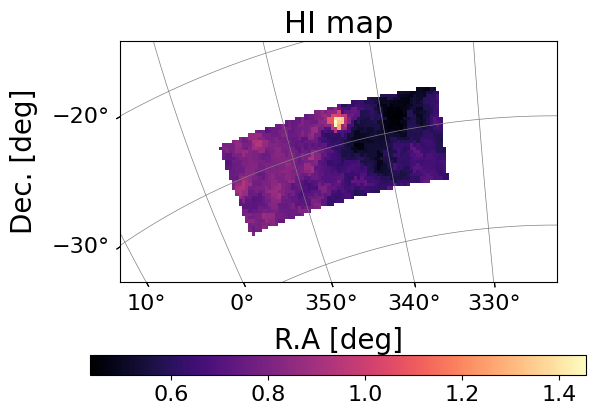

In [7]:
plot_map(fg_map,mock.wproj,W=mock.W_HI,title='HI map')
save_project_plot(plt.gcf(), week_number = 3, filename = "hydrogen_map_w_foreground.pdf")

Note how different the colour scales are. The foregrounds are 4 orders of magnitude larger than the HI. But they are different in the frequency structure (which you read in the paper):

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/frequency_vs_temperature.pdf


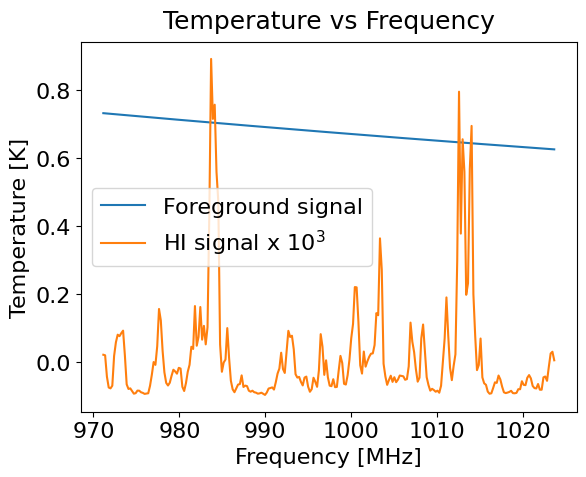

In [361]:
# Just one pixel
fs = 16
plt.plot(mock.nu/1e6, fg_map[60,35], label='Foreground signal')
plt.plot(mock.nu/1e6, hi_map[60,35]*1e3, label='HI signal x $10^3$')
plt.xlabel('Frequency [MHz]', fontsize = fs)
plt.ylabel('Temperature [K]', fontsize = fs)
plt.title('Temperature vs Frequency', fontsize = fs+2, pad = 10)
plt.legend(fontsize =  fs)
save_project_plot(plt.gcf(), week_number = 3, filename = "frequency_vs_temperature.pdf")

Now, we can use the frequency-frequency covariance:

In [18]:
tot_map = hi_map + fg_map

In [19]:
cov_matrix, _, eigen_values, _, = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/total_map_covariance.pdf


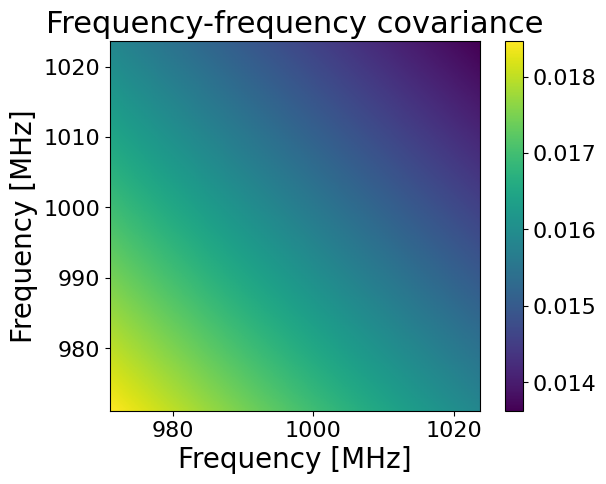

In [20]:
plt.imshow(cov_matrix,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Frequency-frequency covariance')
save_project_plot(plt.gcf(), week_number = 3, filename = "total_map_covariance.pdf")
plt.show()

This is dominated by the foregrounds. If you plot separately the HI:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/foreground_covariance.pdf


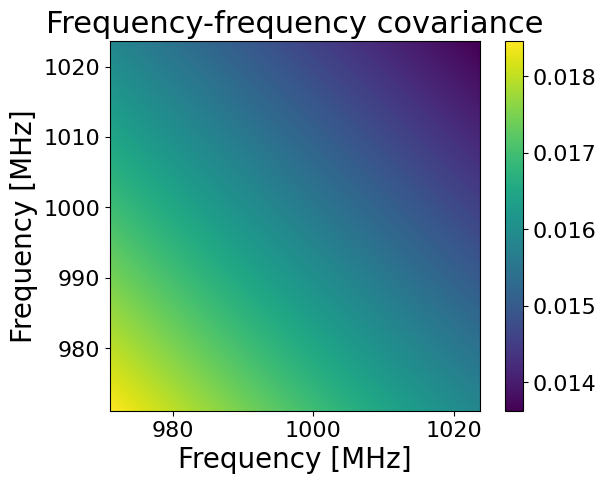

In [21]:
cov_matrix, _, eigen_values, _, = pca_clean(fg_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
plt.imshow(cov_matrix,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Frequency-frequency covariance')
save_project_plot(plt.gcf(), week_number = 3, filename = "foreground_covariance.pdf")
plt.show()

In [22]:
cov_hi, _, _, _, = pca_clean(hi_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/HI_covariance.pdf


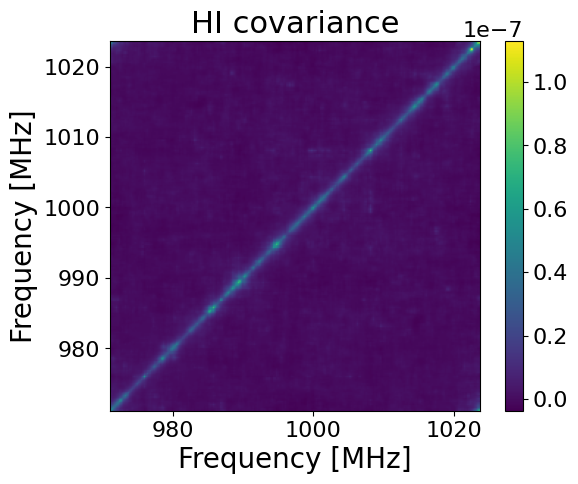

In [23]:
plt.imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('HI covariance')
save_project_plot(plt.gcf(), week_number = 3, filename = "HI_covariance.pdf")
plt.show()

Foreground creates eigenvalues that are distinctly large:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week4/eigenvalues.pdf


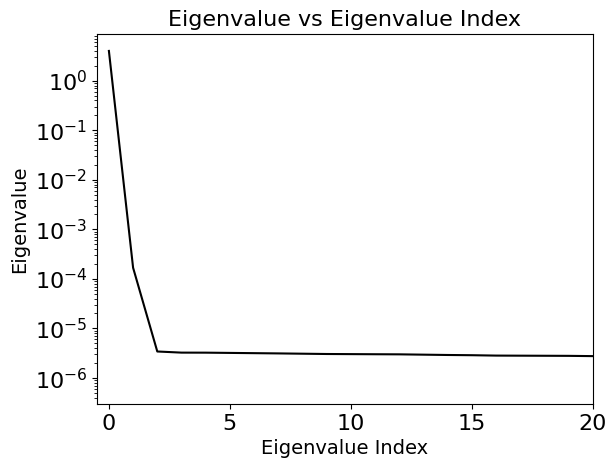

In [369]:
fs = 14
plt.plot(eigen_values, color='black', linestyle='-',)
plt.xlabel('Eigenvalue Index', fontsize = fs)
plt.ylabel('Eigenvalue', fontsize = fs)
plt.title('Eigenvalue vs Eigenvalue Index', fontsize = fs+2)
plt.yscale('log')
plt.xlim(-0.5,20)
save_project_plot(plt.gcf(), week_number = 4, filename = "eigenvalues.pdf")

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week4/eigenvalues.pdf


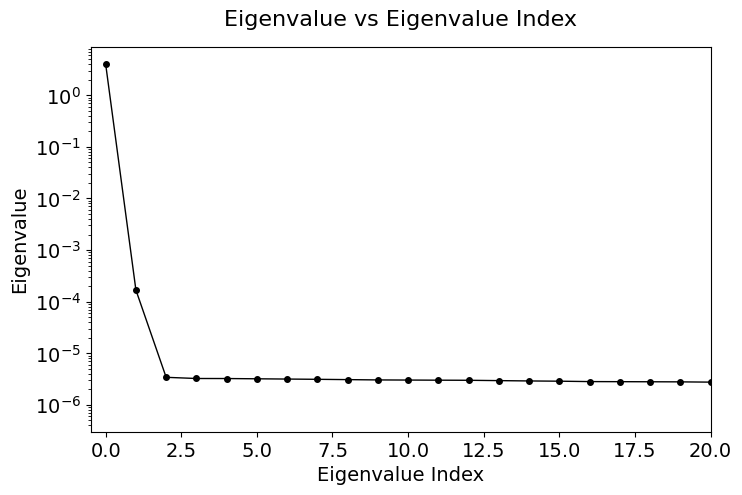

In [368]:
fs = 14

plt.figure(figsize=(8, 5))
plt.plot(eigen_values, marker='o', markersize=4, color='black', linestyle='-', linewidth=1)

# Make both X and Y axis numbers (labels) larger
plt.tick_params(axis='both', which='major', labelsize=fs)

# Specifically for the log scale y-axis: make the minor tick labels larger too if they appear
plt.tick_params(axis='y', which='minor', labelsize=fs-4)

plt.yscale('log')
plt.xlabel('Eigenvalue Index', fontsize=fs)
plt.ylabel('Eigenvalue', fontsize=fs)
plt.title('Eigenvalue vs Eigenvalue Index', fontsize=fs+2, pad=15)

plt.xlim(-0.5, 20)
#plt.grid(True, axis='y', which="both", ls="-", alpha=0.2)

save_project_plot(plt.gcf(), week_number=4, filename="eigenvalues.pdf")
plt.show()

You can see the first 3 modes [0,1,2] are large, and then it plateaus. So let's remove 3 modes:

In [31]:
res_map = pca_clean(tot_map,3,weights=mock.w_HI,return_analysis=False,mean_center=True)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/hydrogen_map_wo_3_modes.pdf


<Figure size 640x480 with 0 Axes>

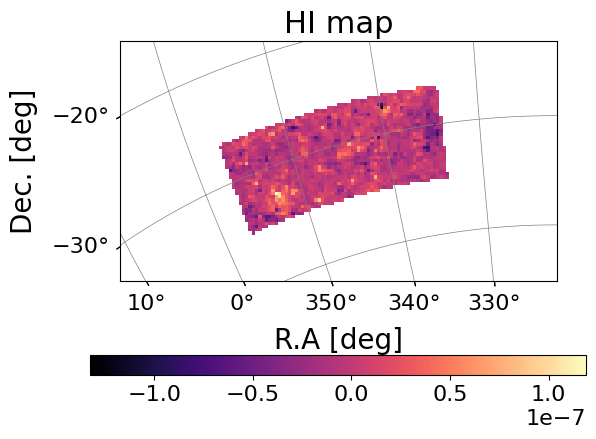

In [32]:
save_project_plot(plt.gcf(), week_number = 3, filename = "hydrogen_map_wo_3_modes.pdf")
plot_map(res_map,mock.wproj,W=mock.W_HI,title='HI map')

The original HI power spectrum is:

In [33]:
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)
mock.k1dbins = np.linspace(0, 1.2, 21)

In [34]:
mock.data = hi_map
mock.grid_data_to_field();
power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = res_map
mock.grid_data_to_field();
power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)

Let us compare the 1d power spectra first:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1D_power_spectrum_comparison_hi_map.pdf


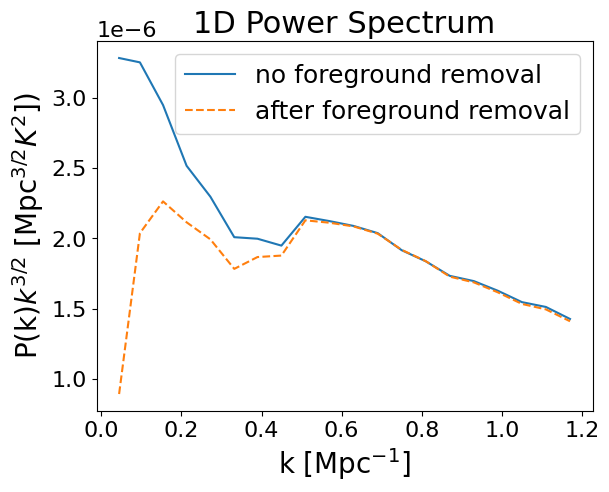

In [35]:
plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal')
plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
plt.title('1D Power Spectrum')
plt.legend()
save_project_plot(plt.gcf(), week_number = 5, filename = "1D_power_spectrum_comparison_hi_map.pdf")
plt.show()



You can see that the foreground cleaned signal has signal loss compared to the original, especially at small k.

Now let us look at cylindrical power spectrum:

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_hi_map.pdf


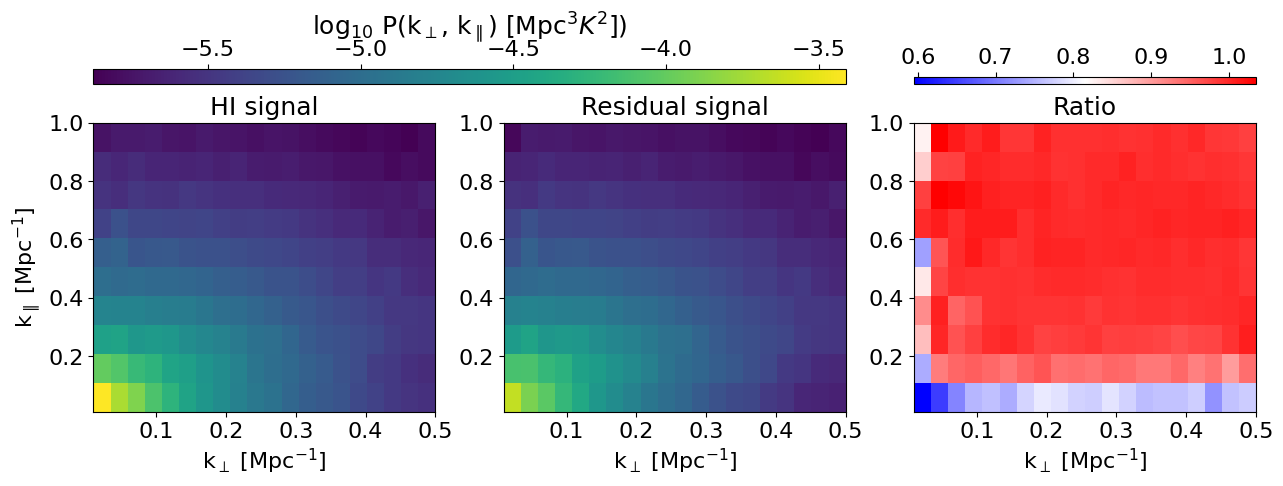

In [47]:
fs = 16
vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2)
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 5, filename = "cylindrical_power_spectrum_hi_map.pdf")
plt.show()

## Eigenvectors

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week4/eigenvectors.pdf


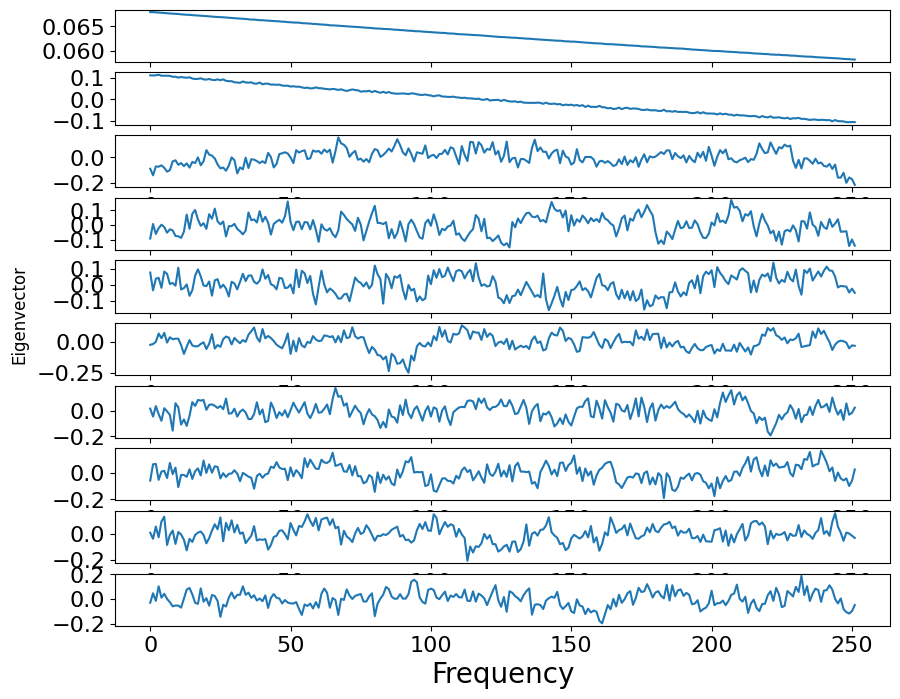

In [342]:
# adding in a noise component
# generating gaussian white noise, this represents the thermal noise of the instrument
# by multiplying by mock.w_HI, this ensures the noise levels are consistent with how the telescope observes the sky
sigma_noise = 1.21 * 1e-3
noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI

# generate a map with the hydrogen signal, forground, and noise component
tot_map = hi_map + fg_map + noise_map
cov_matrix, _, eigen_values, eigen_vectors, = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

# plot the first 10 eigenvectors
fig,axes = plt.subplots(10,1,figsize=(10,8))

for i in range(10):
    axes[i].plot(eigen_vectors[:,i])
    #axes[i].plot(mock.nu/1e6)
    
# Center the y-label across the whole figure
fig.supylabel('Eigenvector', fontsize=12)

# Set the x-label on the bottom
axes[-1].set_xlabel('Frequency')

save_project_plot(plt.gcf(), week_number = 4, filename = "eigenvectors.pdf")

plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week4/eigenvectors.pdf


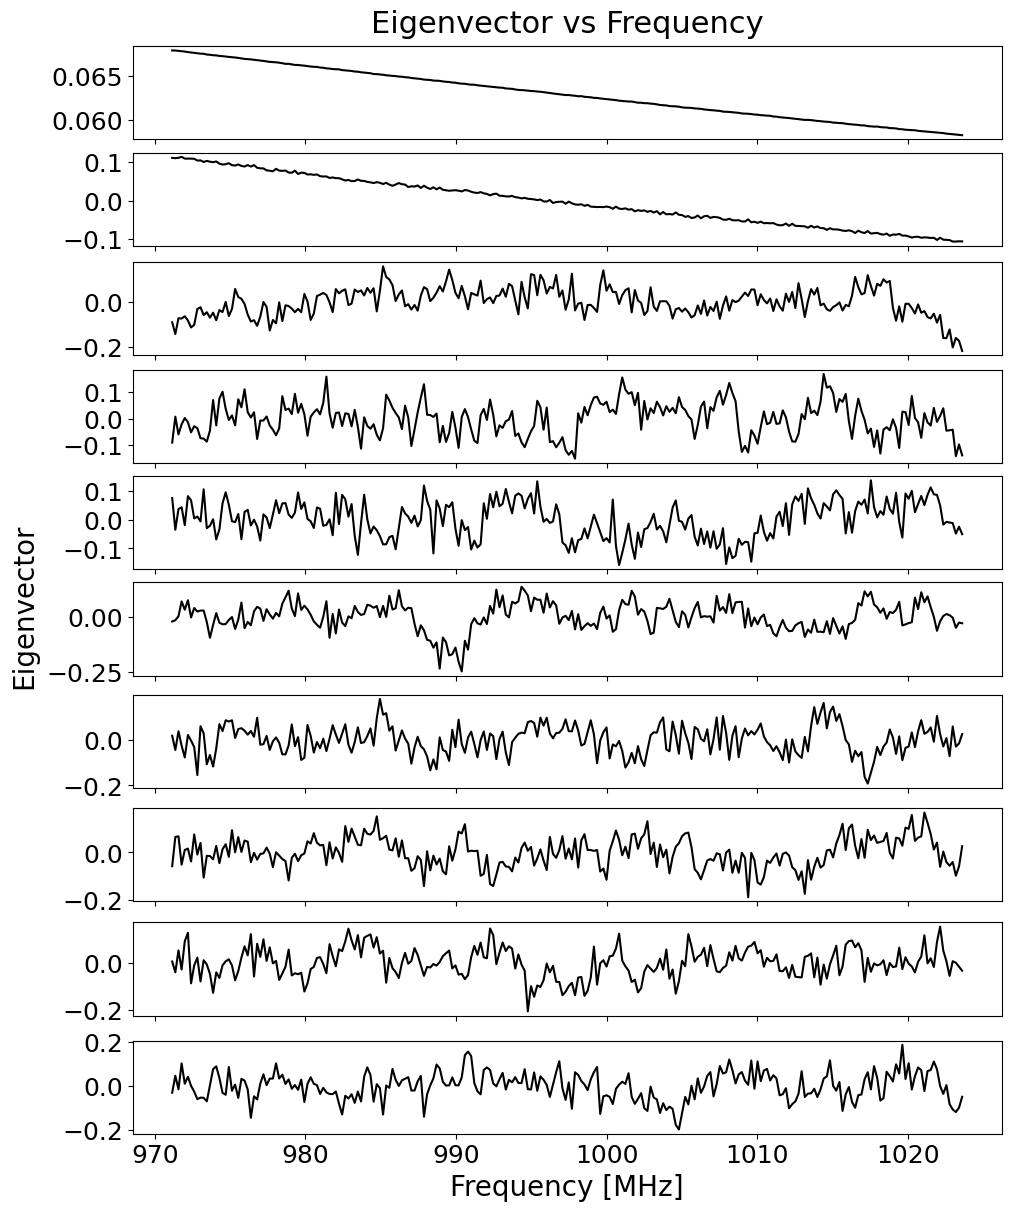

In [371]:
# plot the first 10 eigenvectors with a frequency x-axis
fig, axes = plt.subplots(10, 1, figsize=(10, 12), sharex=True, layout="constrained")

fs = 20

for i in range(10):
    axes[i].plot(mock.nu/1e6, eigen_vectors[:, i], color='black', linestyle='-',)
    
    # Make the tick numbers and marks larger for each subplot
    axes[i].tick_params(axis='both', which='major', labelsize=fs-2)

# Center the y-label across the whole figure
fig.supylabel('Eigenvector', fontsize=fs)

# Set the x-label on the bottom
axes[-1].set_xlabel('Frequency [MHz]', fontsize=fs)
axes[0].set_title('Eigenvector vs Frequency', fontsize=fs+2, pad=10)

save_project_plot(plt.gcf(), week_number=4, filename="eigenvectors.pdf")
plt.show()

# Plotting HI signal, foreground, noise power spectra

## HI 

In [23]:
map_type = "hi"
k_1d, power_1d_hi, power_1d_res, power_cy_hi, power_cy_res = generate_power_spectrum_data(42, fg_map, k_perppara_min = None, k_perppara_max = None, map_type = map_type)

NameError: name 'generate_power_spectrum_data' is not defined

In [ ]:
# not plotting any error bars since it's just one realisation
#plot_1d_log_power_spectrum([k_1d], [power_1d_hi], [power_1d_res], k_perppara_min = None, k_perppara_max = None, 
                           #errors = False, map_type = map_type, save_plot = True, week_number = 5)
#plot_1d_power_spectrum([k_1d], [power_1d_hi], [power_1d_res], k_perppara_min = None, k_perppara_max = None, 
                       #errors = False, map_type = map_type, save_plot = True, week_number = 5)
plot_cylindrical_power_spectrum([power_cy_hi], [power_cy_res], k_perppara_min = None, k_perppara_max = None, 
                                map_type = map_type, save_plot = False, week_number = 5)


## Foreground 

In [ ]:
map_type = "fg"
k_1d, power_1d_fg, power_1d_res, power_cy_fg, power_cy_res = generate_power_spectrum_data(42, fg_map, k_perppara_min = None, k_perppara_max = None, map_type = map_type)


In [ ]:
# not plotting any error bars since it's just one realisation
#plot_1d_log_power_spectrum([k_1d], [power_1d_fg], [power_1d_res], k_perppara_min = None, k_perppara_max = None, 
#                           errors = False, map_type = map_type, save_plot = True, week_number = 5)
#plot_1d_power_spectrum([k_1d], [power_1d_fg], [power_1d_res], k_perppara_min = None, k_perppara_max = None, 
#                       errors = False, map_type = map_type, save_plot = True, week_number = 5)
plot_cylindrical_power_spectrum([power_cy_fg], [power_cy_res], k_perppara_min = None, k_perppara_max = None, 
                                map_type = map_type, save_plot = False, week_number = 5)

## Noise

In [ ]:
map_type = "noise"
k_1d, power_1d_fg, power_1d_res, power_cy_fg, power_cy_res = generate_power_spectrum_data(42, fg_map, k_perppara_min = None, k_perppara_max = None, map_type = map_type)


In [ ]:
# not plotting any error bars since it's just one realisation
#plot_1d_log_power_spectrum([k_1d], [power_1d_fg], [power_1d_res], k_perppara_min = None, k_perppara_max = None, 
#                           errors = False, map_type = map_type, save_plot = True, week_number = 5)
#plot_1d_power_spectrum([k_1d], [power_1d_fg], [power_1d_res], k_perppara_min = None, k_perppara_max = None, 
#                       errors = False, map_type = map_type, save_plot = True, week_number = 5)
plot_cylindrical_power_spectrum([power_cy_fg], [power_cy_res], k_perppara_min = None, k_perppara_max = None, 
                                map_type = map_type, save_plot = False, week_number = 5)

You can see the main signal loss happens at low $k_\parallel$. 

Now a few tasks for you to think about:
- What is $k_\parallel$, and how does it relate to the frequency structure of the foreground?
- In `mock.get_1d_power`, you can select what $k$-modes are getting averaged into the 1D. See [this link](https://meer21cm.readthedocs.io/en/latest/meer21cm.html#meer21cm.power.PowerSpectrum.get_1d_power). Read the documentation and choose the `k_perppara_min` and `k_perppara_max` to select modes that give good agreement.
- Again, run multiple seeds (note foreground map simulation only needs to run once)

### what is k para?
k para is the modes along the redshift/frequency direction. it probes structures along the frequency axis? 
small k para means large-scale variations in the frequency = smooth in frequency (galactic synchotron, free-free emission, and point sources)
large k para means rapid variations in frequency = HI signal more variation 

## define functions

### generating data and foreground removal

In [219]:
# function created in notebook 1
# altered for inputs of k_perppara_min and k_perppara_max
# this is called by generate_power_spectrum_data_100_realisations() which runs this function 100 times with different seeds
def generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, map_type = "hi"):

    # check if seed is an integer
    if not isinstance(seed, (int, np.integer)):
        
        print("Error: The seed must be an integer.")
        return

    # generate mock data according to seed
    mock = MockSimulation(
        survey='meerklass_2021',
        band='L',
        ra_range=(334, 357),
        dec_range=(-35, -26.5),
        flat_sky=True,
        seed=seed,
        omega_hi=5e-4,
        mean_amp_1='average_hi_temp',
        tracer_bias_1=1.0,
    )

    # didn't include foreground simulation since we only need to include it once?

    # create map from generated data
    hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
    #fg_map = fgsim.fg_wcs_cube(mock.nu) # don't need to load this in?

    # create noise map
    sigma_noise = 1.21 * 1e-3
    noise_map = np.random.default_rng(mock.seed).normal(0, sigma_noise, hi_map.shape) * mock.w_HI

    if map_type == "hi":
        map = hi_map
        tot_map = hi_map + fg_map #+ noise_map
        
    elif map_type == "fg":
        map = fg_map
        tot_map = hi_map + fg_map #+ noise_map
        
    elif map_type == "noise":
        map = noise_map
        tot_map = hi_map + fg_map #+ noise_map
        
    else: 
        print("Invalid map type")
        return 

    #tot_map = hi_map + fg_map + noise_map 

    # remove first 3 modes
    res_map = pca_clean(tot_map,3,weights=mock.w_HI,return_analysis=False,mean_center=True)

    # bins
    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins = np.linspace(0, 1.2, 21)
    
    # no foreground removal
    mock.data = map
    mock.grid_data_to_field();
    power_cy_map,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_map,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)

    # with foreground removal
    mock.data = res_map            # this is the hi_map + fg_map with the 3 modes removed
    mock.grid_data_to_field();
    power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1, 
                                                    k_perppara_min = k_perppara_min, 
                                                    k_perppara_max = k_perppara_max) # add in inputs here

    return k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res


In [203]:
# function to call above function and run it with multiprocessing
# also gives progress bar
# altered for inputs of k_perppara_min and k_perppara_max
# where if there is no input, put the default as None (which is the default in the documentation)
def generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min, k_perppara_max, map_type = "hi"):
    
    # start timer
    start_time = time.time()
    
    # run in parallel with progress bar
    results = Parallel(n_jobs=num_processes)(
    delayed(generate_power_spectrum_data)(seed, fg_map, k_perppara_min, k_perppara_max, map_type)
    for seed in tqdm(seeds, desc="Processing seeds", leave=True, position=0))
    
    # calculate time passed and print to update the progress bar
    elapsed_time = time.time() - start_time
    print(f"\nTotal time: {elapsed_time/60:.2f} minutes ({elapsed_time:.2f} seconds)")
    
    # unpack results
    k_1d_list = [result[0] for result in results]
    power_1d_hi_list = [result[1] for result in results]
    power_1d_res_list = [result[2] for result in results]
    power_cy_hi_list = [result[3] for result in results]
    power_cy_res_list = [result[4] for result in results]
    
    # take the means of the 100 realisations
    #k_1d_mean = np.mean(k_1d, axis = 0)
    #power_1d_hi_mean = np.mean(power_1d_hi, axis = 0)
    #power_1d_res_mean = np.mean(power_1d_res, axis = 0)
    #power_cy_hi_mean = np.mean(power_cy_hi, axis = 0)
    #power_cy_res_mean = np.mean(power_cy_res, axis = 0)
    
    # take the standard deviations of the 100 realisations
    #k_1d_std = np.std(k_1d, axis = 0)
    #power_1d_hi_std = np.std(power_1d_hi, axis = 0)
    #power_1d_res_std = np.std(power_1d_res, axis = 0)
    #power_cy_hi_std = np.std(power_cy_hi, axis = 0)
    #power_cy_res_std = np.std(power_cy_res, axis = 0)

    return k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list
    
    #return k_1d_mean, power_1d_hi_mean, power_1d_res_mean, power_cy_hi_mean, power_cy_res_mean, np.abs(k_1d_std), np.abs(power_1d_hi_std), np.abs(power_1d_res_std), np.abs(power_cy_hi_std), np.abs(power_cy_res_std)

### for plots

In [305]:
def plot_1d_log_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min, k_perppara_max, 
                               errors = True, map_type = "hi", save_plot = False, week_number = None):

    fs = 16
    
    # calculate log values
    log_power_1d_hi_list = np.log10(power_1d_hi_list)
    log_power_1d_res_list = np.log10(power_1d_res_list)

    # calculate means
    k_1d_mean = np.mean(k_1d_list, axis = 0)
    log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
    log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

    # calculate standard deviations
    k_1d_std = np.std(k_1d_list, axis = 0)
    log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
    log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

    # plot the log 1D power spectrum
    plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
    plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

    if errors == True:
        plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
        plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

    # add title and labels
    plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
    plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
    plt.title('1D Power Spectrum', fontsize=fs+2)
    plt.tick_params(labelsize=fs-2)
    plt.legend(fontsize=fs)

    # save plot?
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_{map_type}.pdf")

    # show plot
    plt.show()

In [60]:
# function to plot the 1d
def plot_1d_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min, k_perppara_max, 
                           errors = True, map_type = "hi", save_plot = False, week_number = None):

    fs = 16

    # convert to numpy array
    k_1d_list = np.array(k_1d_list)
    power_1d_hi_list = np.array(power_1d_hi_list)
    power_1d_res_list = np.array(power_1d_res_list)

    # calculate y axis values
    #y_axis_before_list = (power_1d_hi_list.T) * k_1d_list**(3/2)
    #y_axis_after_list = (power_1d_res_list.T) * k_1d_list**(3/2)
    y_axis_before_list = (power_1d_hi_list) * k_1d_list**(3/2)
    y_axis_after_list = (power_1d_res_list) * k_1d_list**(3/2)

    # calculate means
    k_1d_mean = np.mean(k_1d_list, axis = 0)
    y_axis_before_mean = np.mean(y_axis_before_list, axis = 0)
    y_axis_after_mean = np.mean(y_axis_after_list, axis = 0)

    # calculate standard deviations
    k_1d_std = np.std(k_1d_list, axis = 0)
    y_axis_before_std = np.std(y_axis_before_list, axis = 0)
    y_axis_after_std = np.std(y_axis_after_list, axis = 0)

    # plot the comparison of the 1d power spectrum 
    plt.plot(k_1d_mean, y_axis_before_mean,label='no foreground removal')
    plt.plot(k_1d_mean, y_axis_after_mean,label='after foreground removal',ls='--')

    # plot errors if True
    if errors == True:
        plt.errorbar(k_1d_mean, y_axis_before_mean, yerr = y_axis_before_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
        plt.errorbar(k_1d_mean, y_axis_after_mean, yerr = y_axis_after_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

    # add titles and labels
    plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
    plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)', fontsize=fs)
    plt.title('1D Power Spectrum', fontsize=fs+2)
    plt.tick_params(labelsize=fs-2)
    plt.legend()

    # save plot?
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"1d_power_spectrum_{k_perppara_min}_{k_perppara_max}_{map_type}.pdf")
    
    plt.show()

In [61]:
def plot_cylindrical_power_spectrum(power_cy_hi_list, power_cy_res_list, k_perppara_min, k_perppara_max, 
                                    map_type = "hi", save_plot = False, week_number = None):

    # bins
    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)

    # convert to arrays
    power_cy_hi_list = np.array(power_cy_hi_list)
    power_cy_res_list = np.array(power_cy_res_list)

    # calculate means
    power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
    power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

    # calculate log values
    log_power_cy_hi_mean = np.log10(power_cy_hi_mean.T)
    log_power_cy_res_mean = np.log10(power_cy_res_mean.T)

    # find minimum and maximum values
    vmin = min(log_power_cy_hi_mean.min(), log_power_cy_res_mean.min())
    vmax = max(log_power_cy_hi_mean.max(), log_power_cy_res_mean.max())
    #vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
    #vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   

    # create empty figures
    fig,axes=plt.subplots(1,3,figsize=(15,5))

    if map_type == "hi":
        title = 'HI power spectrum'
        
    elif map_type == "fg":
        title = 'Foreground'
        
    elif map_type == "noise":
        title = 'Noise'
        
    else: 
        print("Invalid map type")
        return 

    # plot one
    axes[0].pcolormesh(mock.kperpbins, mock.kparabins, log_power_cy_hi_mean, vmin = vmin, vmax = vmax)
    axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize=fs)
    axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize=fs)
    axes[0].set_title('HI signal', fontsize=fs+2)
    axes[0].tick_params(labelsize=fs-2)

    # plot two
    im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, log_power_cy_res_mean, vmin = vmin, vmax = vmax)
    axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize=fs)
    axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize=fs)
    axes[1].set_title('Residual signal', fontsize=fs+2)
    axes[1].tick_params(labelsize=fs-2)

    # colour bar
    cbar1 = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
    cbar1.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
    cbar1.ax.tick_params(labelsize=fs-2)

    # plot three
    im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
    axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize=fs)
    axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize=fs)
    axes[2].set_title('Ratio', fontsize=fs+1)
    axes[2].tick_params(labelsize=fs-2)
    cbar2 = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
    cbar2.ax.tick_params(labelsize=fs-2)

    # save plot?
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}_{map_type}_totmap_wo_noise.pdf")

    # show plot
    plt.show()

## def foreground_removal_1d_and_cylindrical_power_spectrum(save_plot = False, week_number = None, modes_cleaned = None):

    tot_map = hi_map + fg_map
    cov_matrix, _, eigen_values, _, = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
    cov_hi, _, _, _, = pca_clean(hi_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
    res_map = pca_clean(tot_map,modes_cleaned,weights=mock.w_HI,return_analysis=False,mean_center=True)
    
    # original HI power spectrum
    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins = np.linspace(0, 1.2, 21)
    
    mock.data = hi_map
    mock.grid_data_to_field();
    power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = res_map
    mock.grid_data_to_field();
    power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)

    # 1D power spectrum
    plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal', color = 'blue')
    plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--', color = 'red')
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
    plt.title('1D Power Spectrum')
    plt.legend()
    if save_plot:
        save_project_plot(plt.gcf(), week_number=week_number,
                          filename=f"1d_power_spectrum_{modes_cleaned}_{method}.pdf")
    plt.show()
    
    # 1D power spectrum residuals
    y_hi = (power_1d_hi.T) * k_1d**(3/2)
    y_res = (power_1d_res.T) * k_1d**(3/2)
    residual = y_res - y_hi  # difference between cleaned and true HI
    plt.plot(k_1d, residual, color='red', ls = '--', label='residual (after - before)')
    plt.axhline(0, color='blue', linewidth=0.8)  # zero line for reference
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'$\Delta$P(k)$k^{3/2}$ [Mpc$^{3/2}$K$^2$]')
    plt.title('Residual')
    plt.legend()
    if save_plot:
        save_project_plot(plt.gcf(), week_number=week_number,
                          filename=f"1d_power_spectrum_residuals_{modes_cleaned}_{method}.pdf")
    plt.show()

    # 1D power spectrum
    log_power_1d_hi = np.log10(power_1d_hi)
    log_power_1d_res = np.log10(power_1d_res)
    plt.plot(k_1d, log_power_1d_hi, label='no foreground removal', color = 'blue', linewidth = 1)
    plt.plot(k_1d, log_power_1d_res, label='after foreground removal',ls='--', color = 'red', linewidth = 1)
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)')
    plt.title('1D Power Spectrum')
    plt.legend()
    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"log_1d_power_spectrum_{modes_cleaned}_{method}.pdf") 
    plt.show()
    
    # log 1D power spectrum residuals
    y_hi = log_power_1d_hi
    y_res = log_power_1d_res
    residual = y_res - y_hi  # difference between cleaned and true HI
    plt.plot(k_1d, residual, color='red', ls = '--', label='residual (after - before)')
    plt.axhline(0, color='blue', linewidth=0.8)  # zero line for reference
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'$\Delta$P(k)$k^{3/2}$ [Mpc$^{3/2}$K$^2$]')
    plt.title('Residual')
    plt.legend()
    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"log_1d_power_spectrum_residuals_{modes_cleaned}_{method}.pdf")
    plt.show()

    # cylindrical power spectrum
    vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
    vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
    fig,axes=plt.subplots(1,3,figsize=(15,5))
    axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
    axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
    axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
    axes[0].set_title('HI signal', fontsize = fs+2)
    axes[0].tick_params(labelsize=fs-2)
    im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
    axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
    axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
    axes[1].set_title('Residual signal', fontsize = fs+2)
    axes[1].tick_params(labelsize=fs-2)
    cbar1 = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
    cbar1.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs)
    cbar1.ax.tick_params(labelsize=fs-2)
    im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
    axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
    axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
    axes[2].set_title('Ratio', fontsize = fs+2)
    axes[2].tick_params(labelsize=fs-2)
    cbar2 = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
    cbar2.ax.tick_params(labelsize=fs-2)

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"cylindrical_power_spectrum_{modes_cleaned}_{method}.pdf")
        
    plt.show()

In [55]:
# generate a list of 100 integers [1, 2, 3, ..., 100]
seeds = np.arange(1, 101)

# determine number of processes
num_processes = os.cpu_count()
print(f"There are {num_processes} processes")

There are 8 processes


### with no inputs
#### this is just to see if the functions are working as expected

In [46]:
# pass in fg_map generated at the beginning
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = None, k_perppara_max = None)

Processing seeds: 100%|███████████████████████| 100/100 [03:12<00:00,  1.93s/it]



Total time: 3.68 minutes (220.84 seconds)


In [47]:
plot_1d_log_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = None, k_perppara_max = None)
plot_1d_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = None, k_perppara_max = None, errors = True)
plot_1d_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = None, k_perppara_max = None, errors = False)
plot_cylindrical_power_spectrum_foreground_removal(power_cy_hi_list, power_cy_res_list, k_perppara_min = None, k_perppara_max = None)

NameError: name 'plot_1d_log_power_spectrum_foreground_removal' is not defined

### with inputs

In [28]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0, 0.1], k_perppara_max = None)

Processing seeds: 100%|███████████████████████| 100/100 [02:18<00:00,  1.38s/it]



Total time: 2.79 minutes (167.21 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0, 0.1]_None.pdf


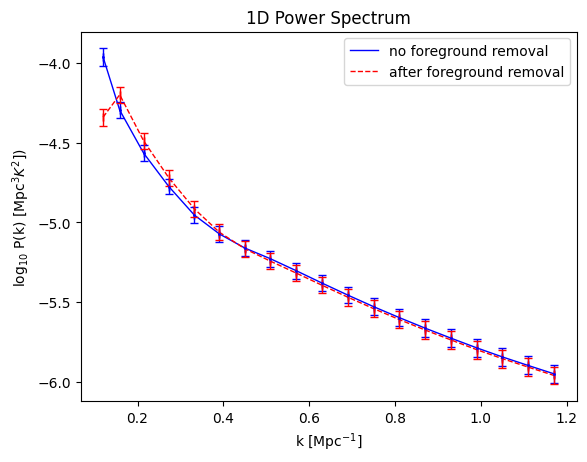

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_power_spectrum_[0, 0.1]_None.pdf


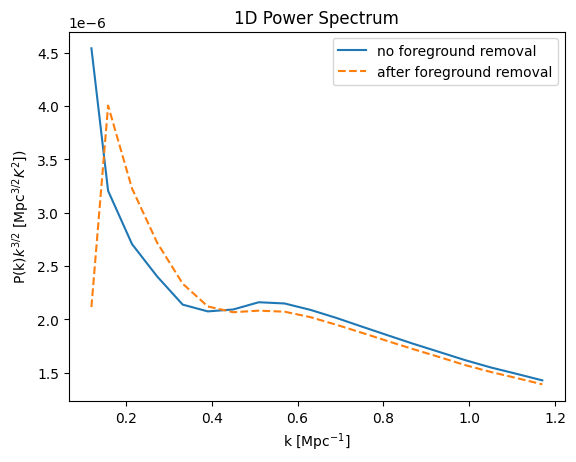

In [29]:
plot_1d_log_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0, 0.1], k_perppara_max = None)
plot_1d_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0, 0.1], k_perppara_max = None, errors = False)

In [30]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.1, 0.1], k_perppara_max = None)

Processing seeds: 100%|███████████████████████| 100/100 [02:22<00:00,  1.43s/it]



Total time: 2.76 minutes (165.60 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0.1, 0.1]_None.pdf


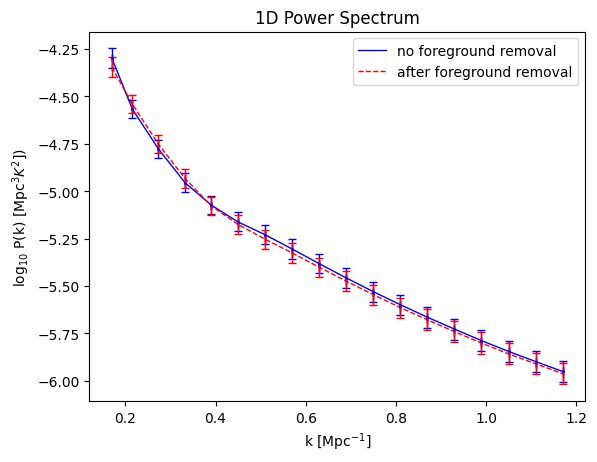

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_power_spectrum_[0.1, 0.1]_None.pdf


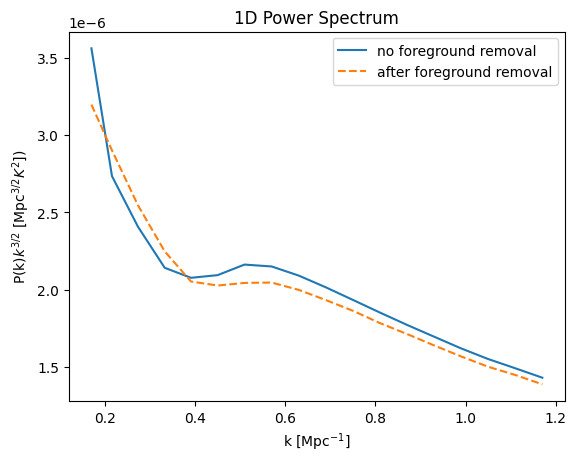

In [31]:
plot_1d_log_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.1, 0.1], k_perppara_max = None)
plot_1d_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.1, 0.1], k_perppara_max = None, errors = False)

In [32]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.05, 0.1], k_perppara_max = None)

Processing seeds: 100%|███████████████████████| 100/100 [02:19<00:00,  1.39s/it]



Total time: 2.77 minutes (166.04 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0.05, 0.1]_None.pdf


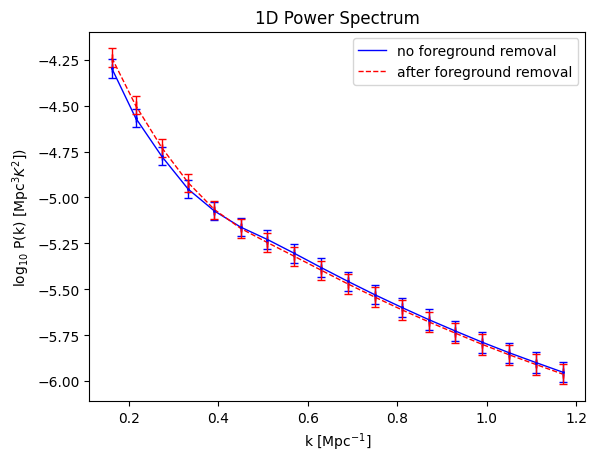

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_power_spectrum_[0.05, 0.1]_None.pdf


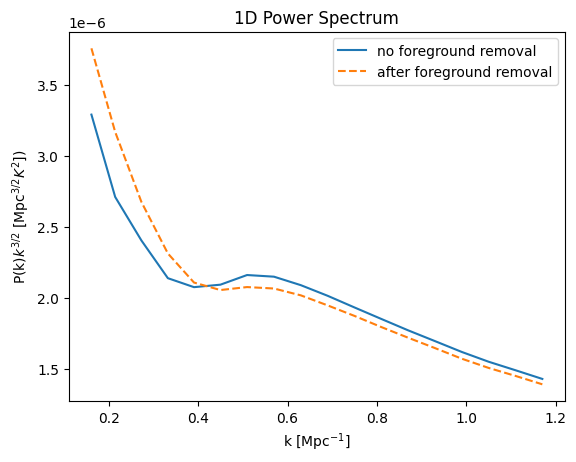

In [33]:
plot_1d_log_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.05, 0.1], k_perppara_max = None)
plot_1d_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.05, 0.1], k_perppara_max = None, errors = False)

In [34]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.025, 0.1], k_perppara_max = None)

Processing seeds: 100%|███████████████████████| 100/100 [02:20<00:00,  1.41s/it]



Total time: 2.75 minutes (164.86 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0.025, 0.1]_None.pdf


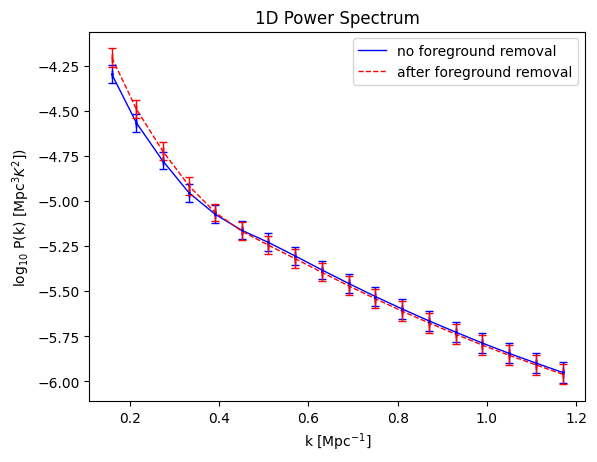

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_power_spectrum_[0.025, 0.1]_None.pdf


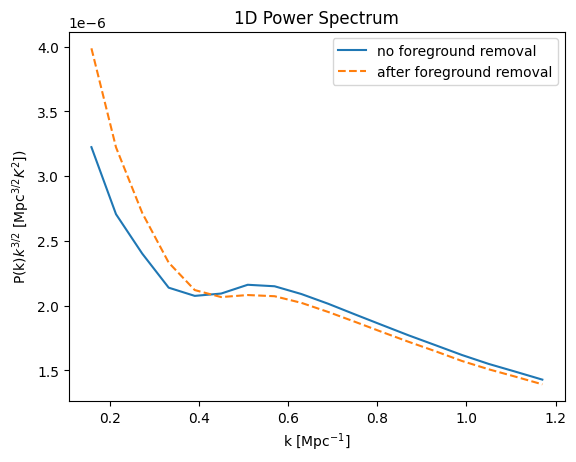

In [35]:
plot_1d_log_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0.1], k_perppara_max = None)
plot_1d_power_spectrum_foreground_removal(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0.1], k_perppara_max = None, errors = False)

In [12]:

k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.025, 0], k_perppara_max = None)



Processing seeds: 100%|███████████████████████| 100/100 [03:01<00:00,  1.81s/it]



Total time: 3.67 minutes (219.92 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0.025, 0]_None_hi.pdf


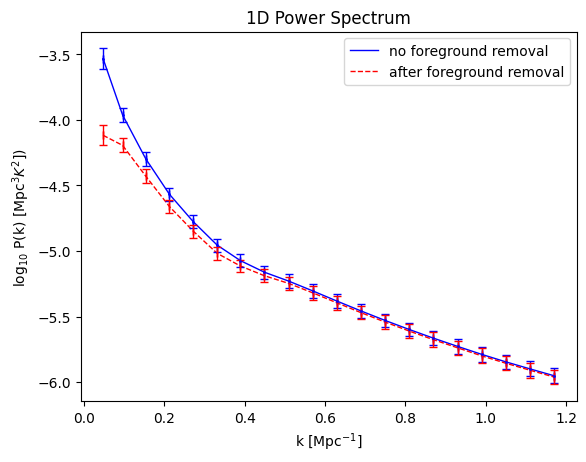

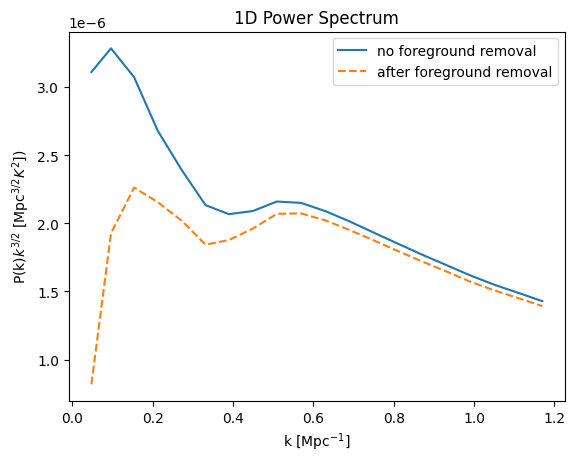

In [15]:
plot_1d_log_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0], k_perppara_max = None, save_plot = True, week_number = 3)
plot_1d_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0], k_perppara_max = None, errors = False)

In [27]:

k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.025, 0.05], k_perppara_max = None)



Processing seeds: 100%|███████████████████████| 100/100 [03:11<00:00,  1.91s/it]



Total time: 3.80 minutes (227.75 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0.025, 0.05]_None_hi.pdf


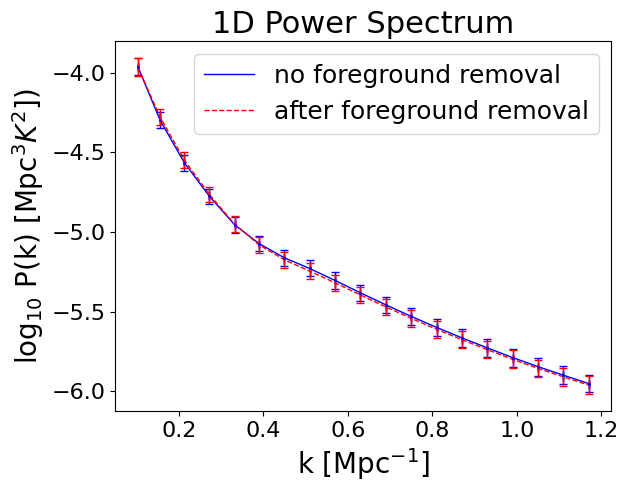

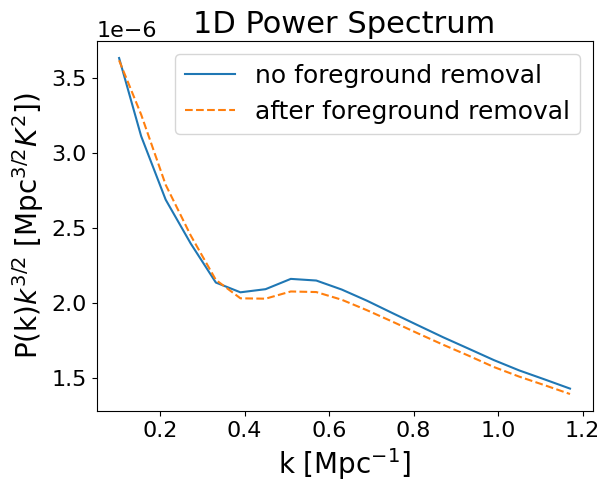

In [28]:
plot_1d_log_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0.05], k_perppara_max = None, save_plot = True, week_number = 3)
plot_1d_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0.05], k_perppara_max = None, errors = False)

In [29]:

k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.025, 0.08], k_perppara_max = None)



Processing seeds: 100%|███████████████████████| 100/100 [03:19<00:00,  1.99s/it]



Total time: 3.80 minutes (228.04 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week3/1d_log_power_spectrum_[0.025, 0.08]_None_hi.pdf


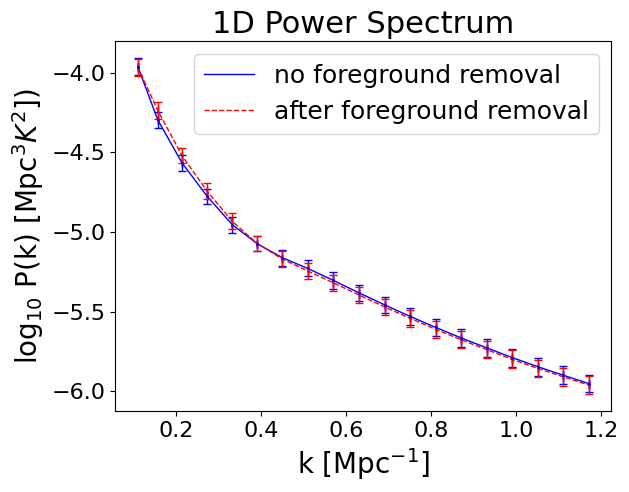

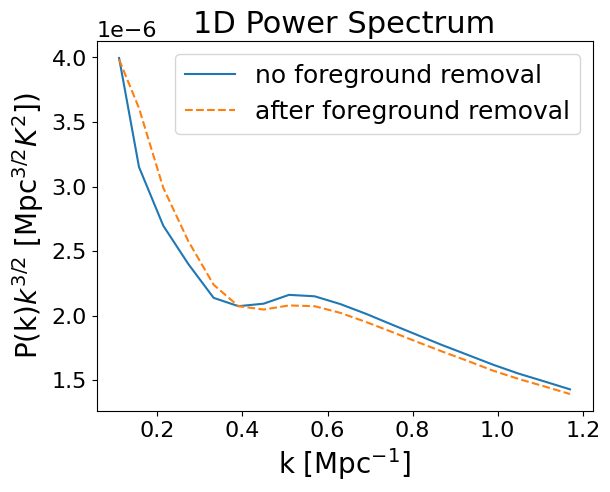

In [30]:
plot_1d_log_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0.08], k_perppara_max = None, save_plot = True, week_number = 3)
plot_1d_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.025, 0.08], k_perppara_max = None, errors = False)

In [31]:

k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0.0, 0.1], k_perppara_max = None)



Processing seeds:  33%|███████▉                | 33/100 [00:47<01:42,  1.53s/it]

KeyboardInterrupt: 

In [ ]:
plot_1d_log_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.0, 0.1], k_perppara_max = None, save_plot = True, week_number = 3)
plot_1d_power_spectrum(k_1d_list, power_1d_hi_list, power_1d_res_list, k_perppara_min = [0.0, 0.1], k_perppara_max = None, errors = False)

# Let's try PCA but only clean 0, 1, 2, 3 modes

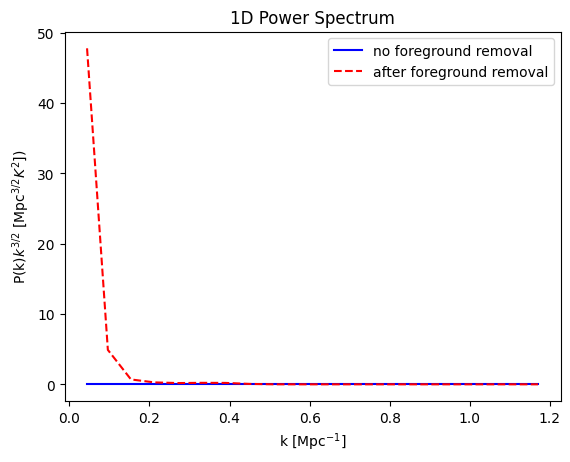

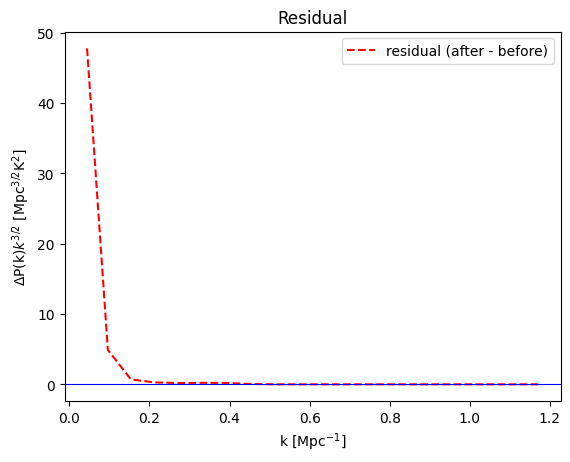

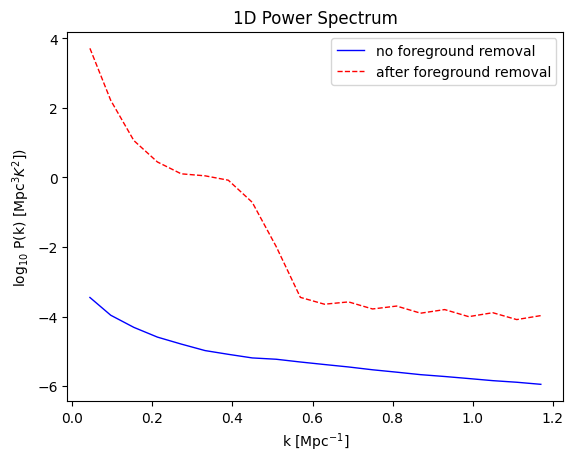

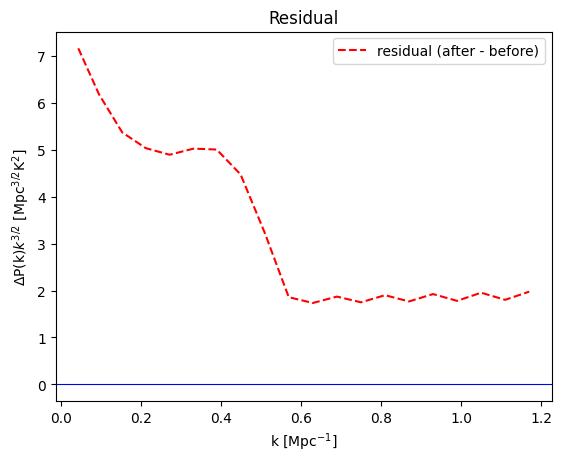

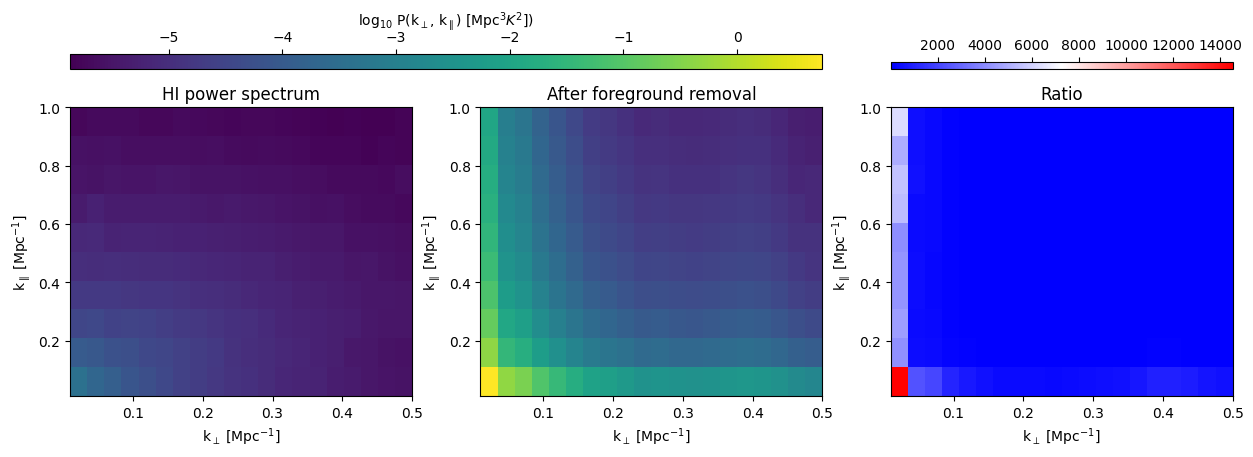

In [47]:
foreground_removal_1d_and_cylindrical_power_spectrum(save_plot = False, week_number = None, modes_cleaned = 0)

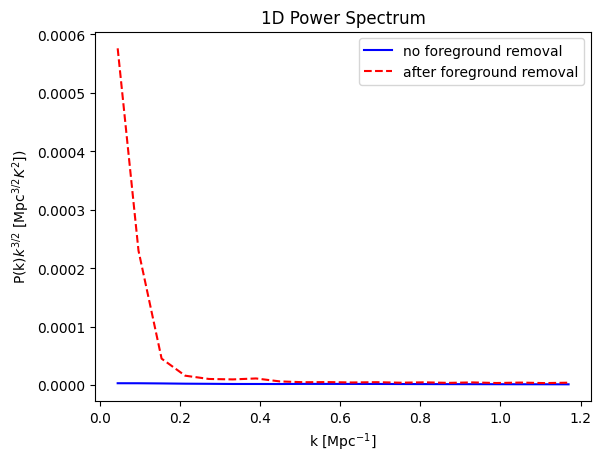

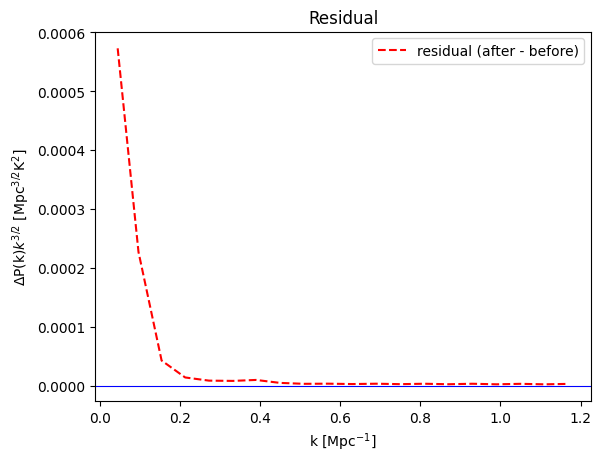

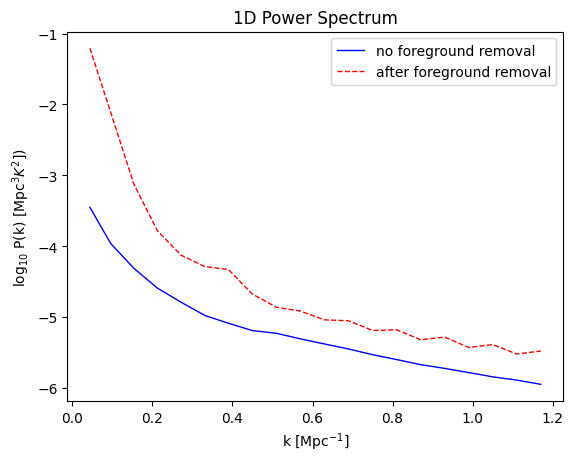

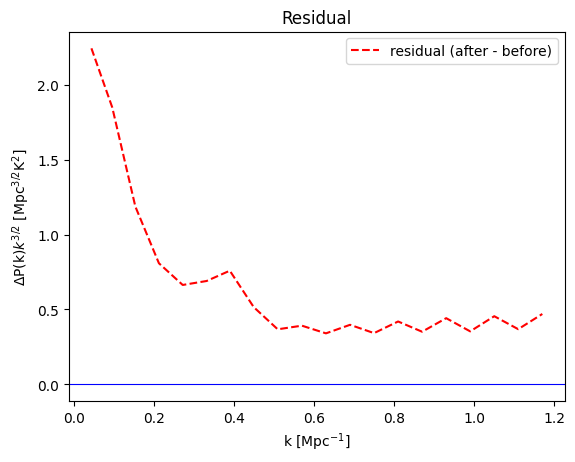

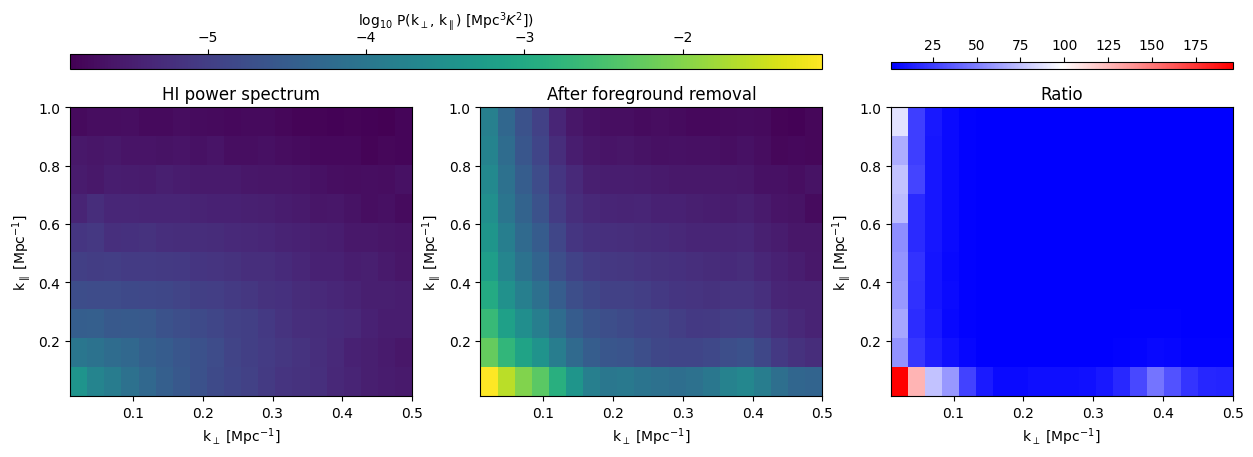

In [48]:
foreground_removal_1d_and_cylindrical_power_spectrum(save_plot = False, week_number = None, modes_cleaned = 1)

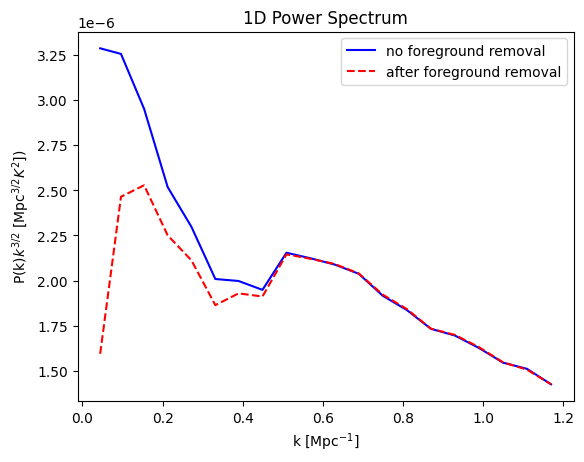

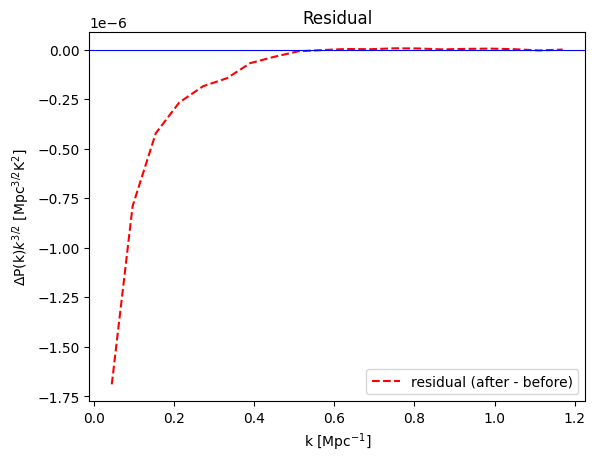

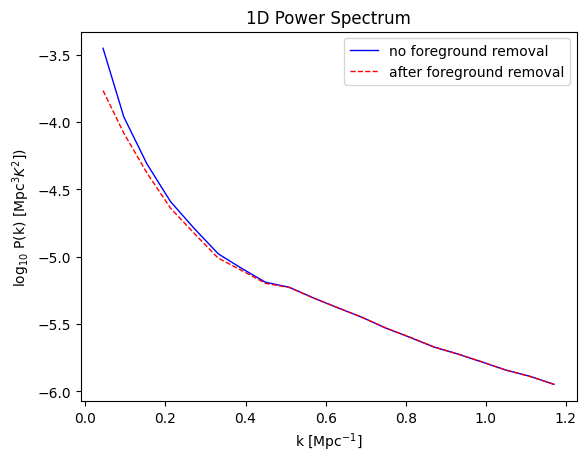

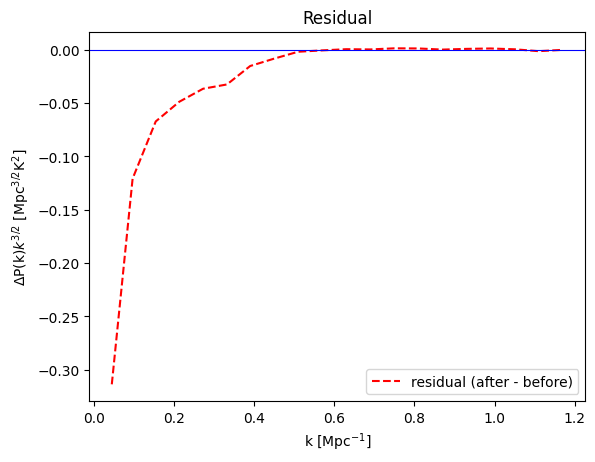

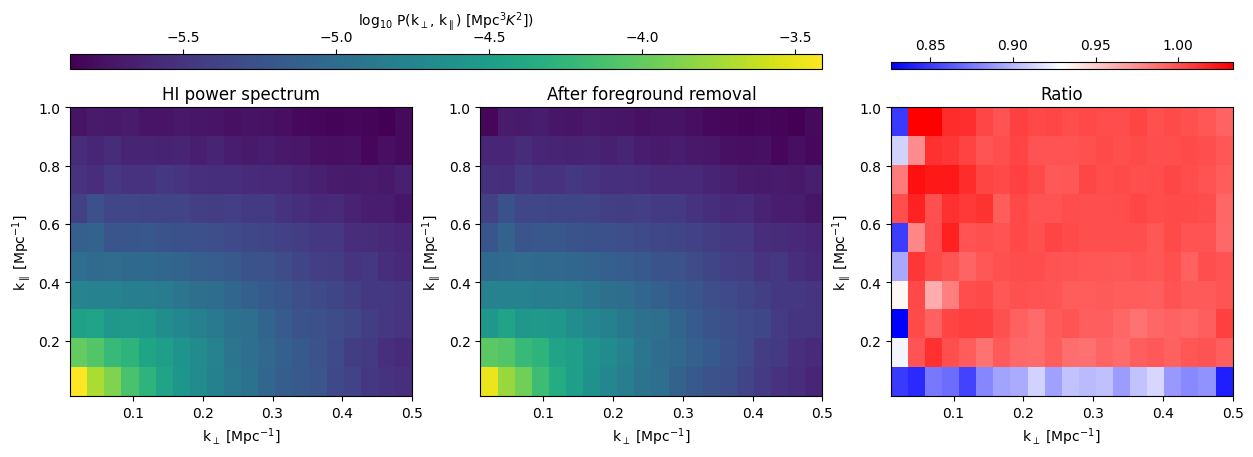

In [49]:
foreground_removal_1d_and_cylindrical_power_spectrum(save_plot = False, week_number = None, modes_cleaned = 2)

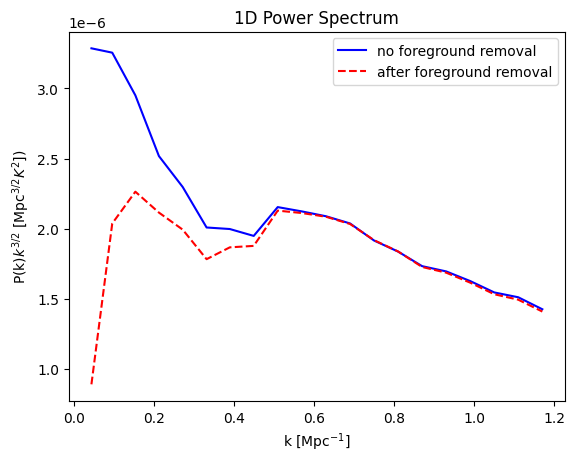

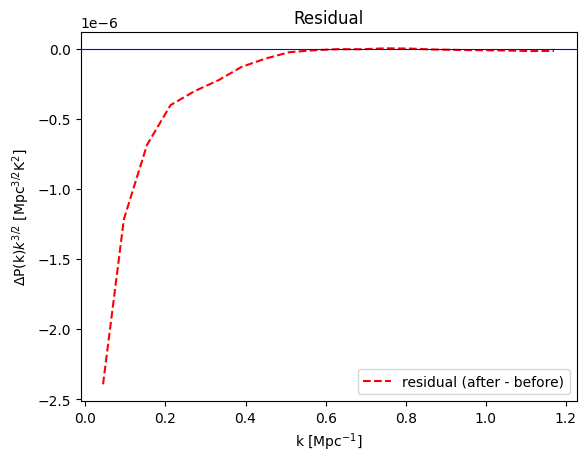

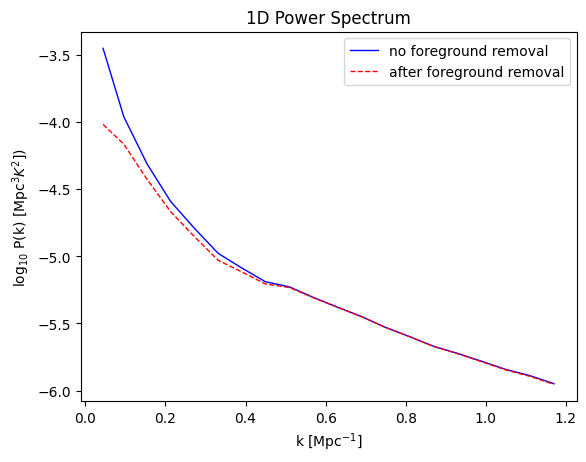

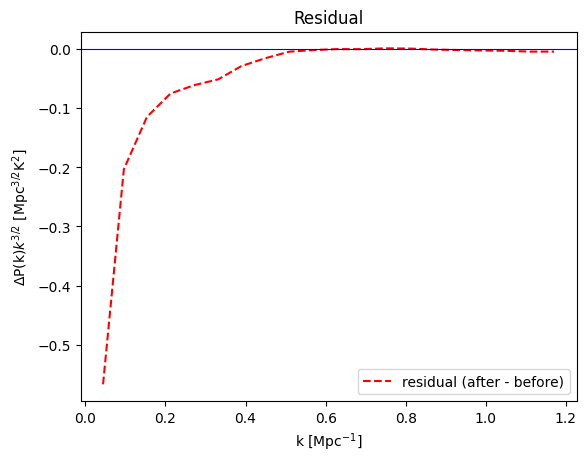

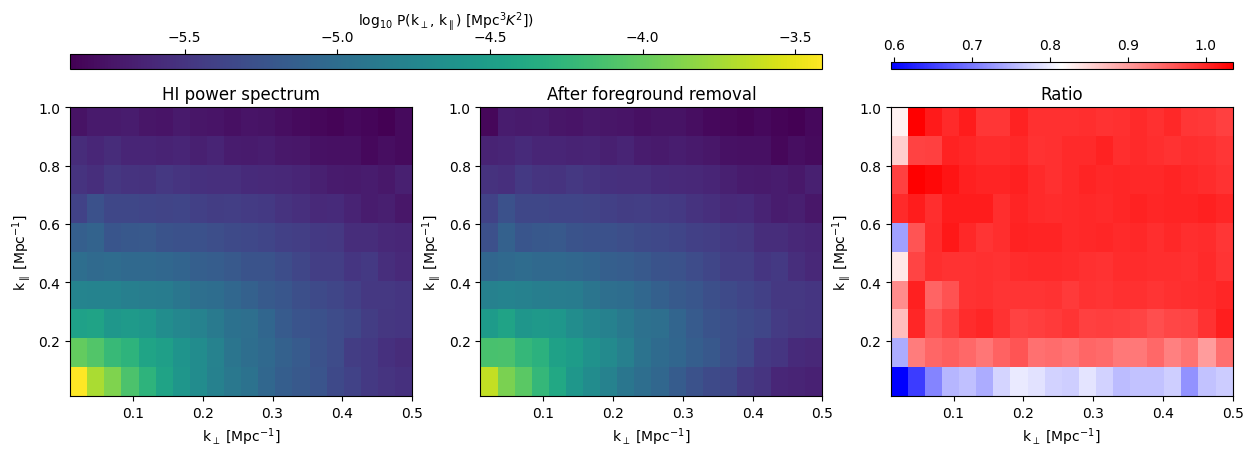

In [50]:
foreground_removal_1d_and_cylindrical_power_spectrum(save_plot = False, week_number = None, modes_cleaned = 3)

# Report graphs

In [187]:
seed = 42
k_perppara_min = None
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]

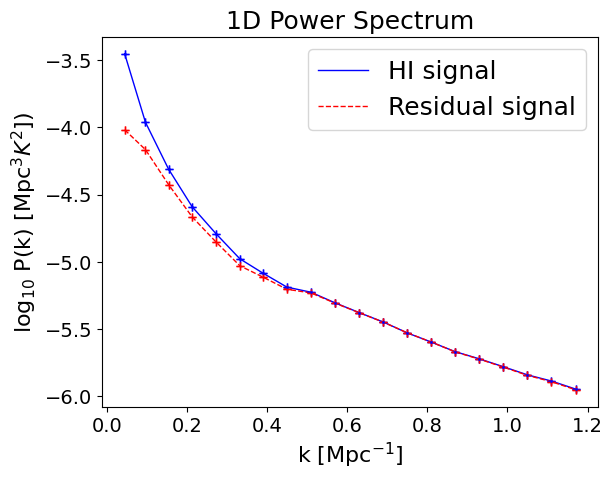

In [188]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend()

#save_project_plot(plt.gcf(), week_number = week_number, 
#                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_{map_type}.pdf")

# show plot
plt.show()



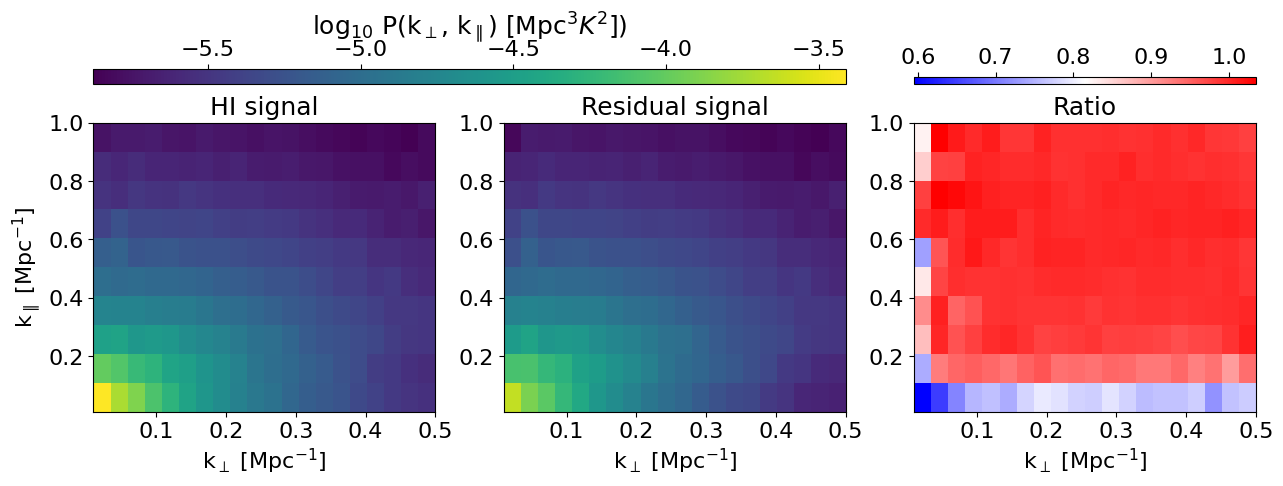

In [189]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))

axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)

im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2)

im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)

#save_project_plot(plt.gcf(), week_number = 5, filename = "cylindrical_power_spectrum_hi_map.pdf")
plt.show()

In [193]:
seed = 42
k_perppara_min = [0, 0.03]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]


In [196]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = [0, 0.03], k_perppara_max = None)




Processing seeds: 100%|███████████████████████| 100/100 [01:17<00:00,  1.29it/s]



Total time: 1.59 minutes (95.62 seconds)


Created new directory: /Users/gracetait/shproject/senior_honours_project/outputs/week9
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.03]_None.pdf


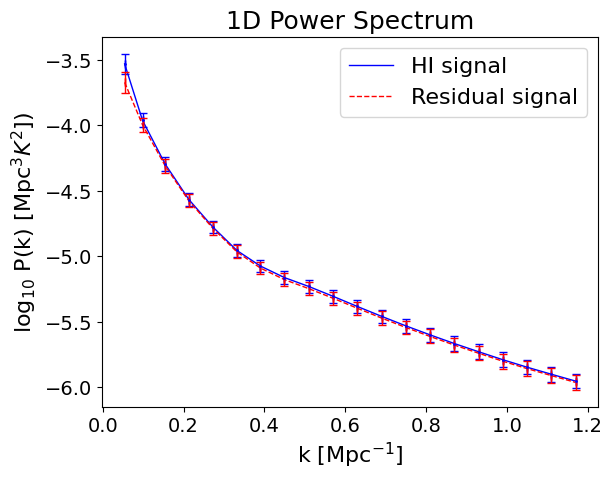

In [200]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf


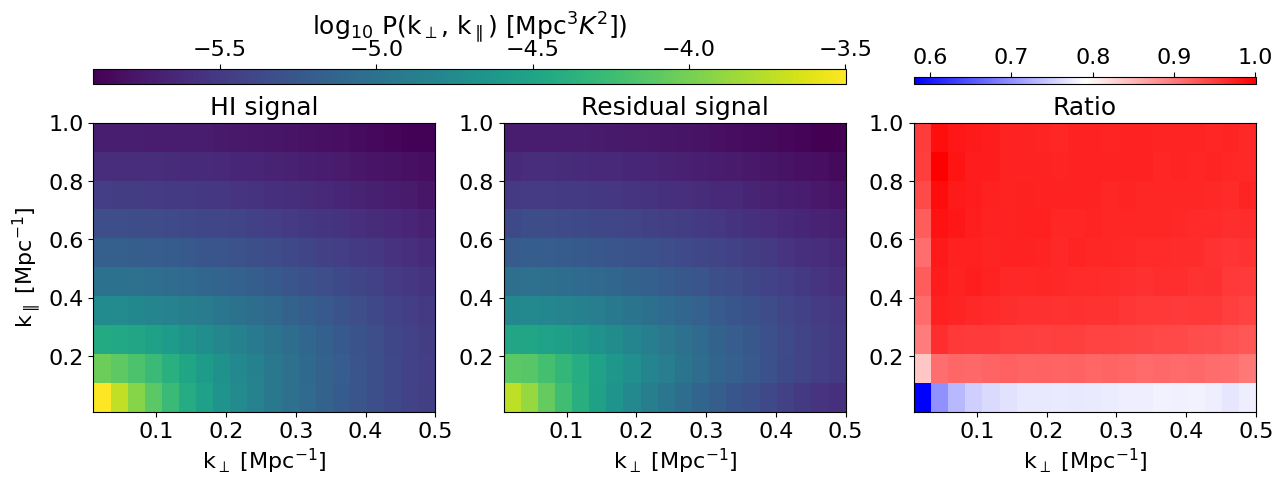

In [201]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2)
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 5, filename = "cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [273]:
seed = 42
k_perppara_min = [0.025, 0.6]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [274]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds:   0%|                                 | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0.025, 0.1]_None.pdf


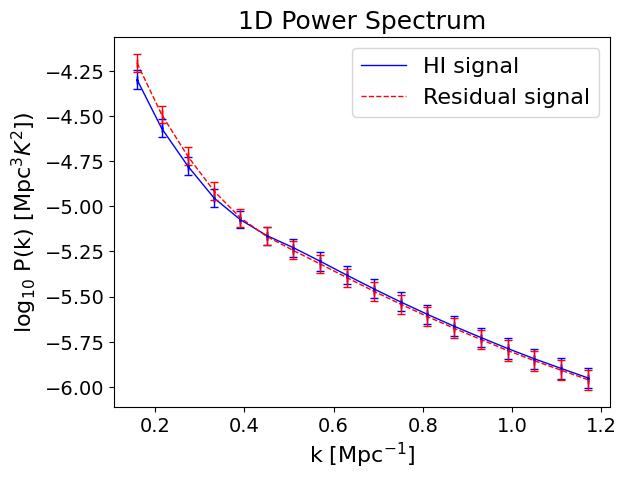

In [226]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



In [ ]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2)
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
save_project_plot(plt.gcf(), week_number = 5, filename = "cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [265]:
seed = 42
k_perppara_min = [0, 0.08]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [266]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:18<00:00,  1.27it/s]



Total time: 1.56 minutes (93.79 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.08]_None.pdf


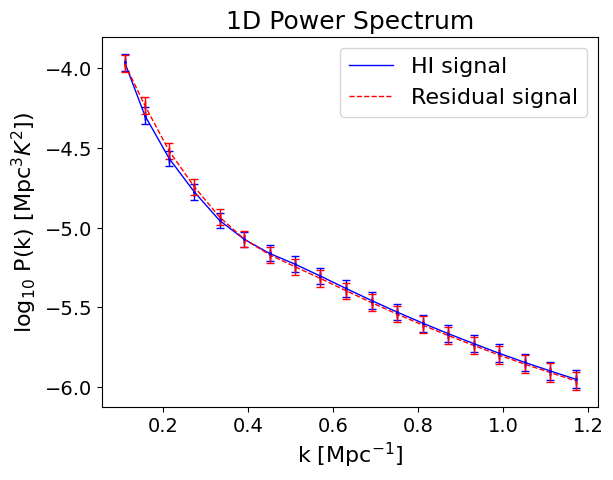

In [267]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_[0, 0.08]_None.pdf


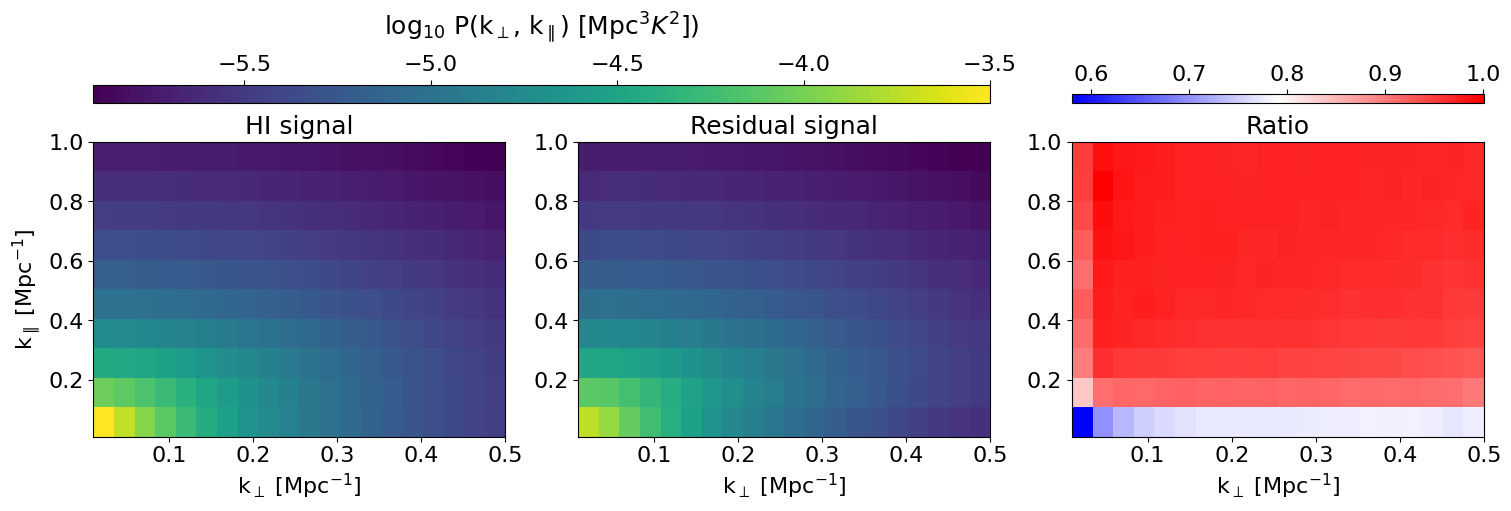

In [268]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.04)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2, labelpad = 15)
cbar.ax.set_position([pos0.x0, pos0.y0 + 5, pos0.width, pos0.height])
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.04)
save_project_plot(plt.gcf(), week_number = 5, filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [261]:
seed = 42
k_perppara_min = [0, 0.06]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [262]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:13<00:00,  1.37it/s]



Total time: 1.54 minutes (92.61 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.06]_None.pdf


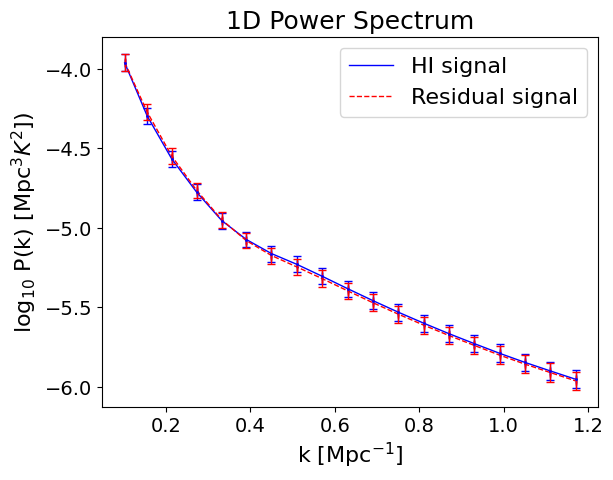

In [263]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_[0, 0.06]_None.pdf


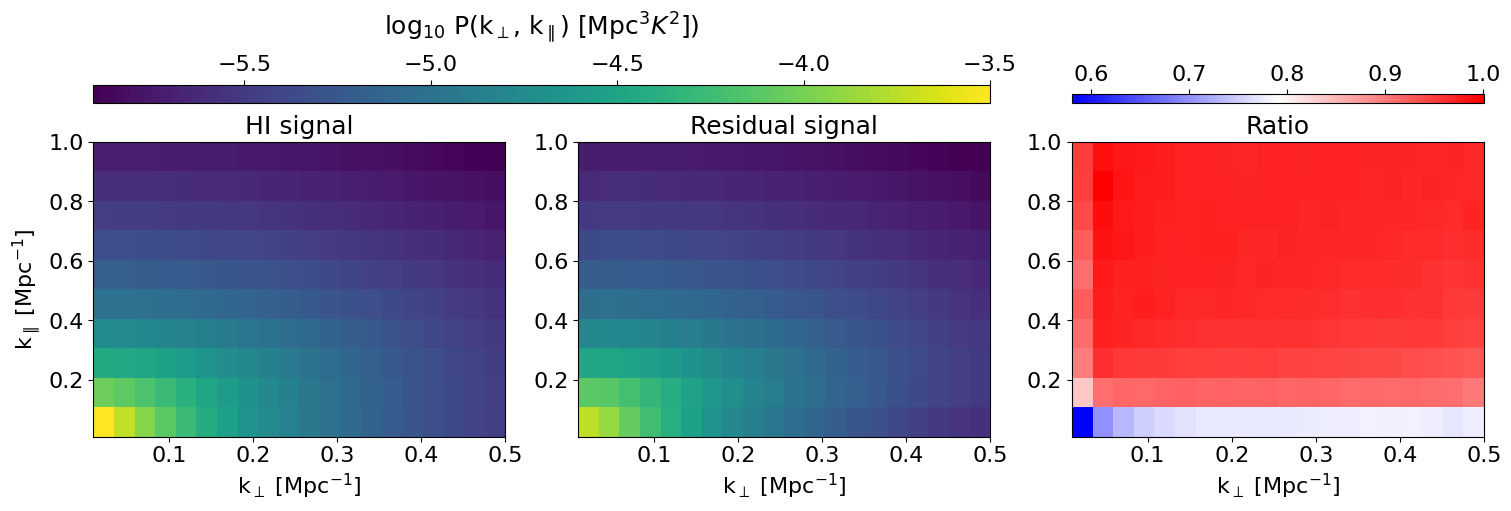

In [264]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.04)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2, labelpad = 15)
cbar.ax.set_position([pos0.x0, pos0.y0 + 5, pos0.width, pos0.height])
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.04)
save_project_plot(plt.gcf(), week_number = 5, filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [269]:
seed = 42
k_perppara_min = [0, 0.1]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [270]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:25<00:00,  1.17it/s]



Total time: 1.82 minutes (109.50 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.1]_None.pdf


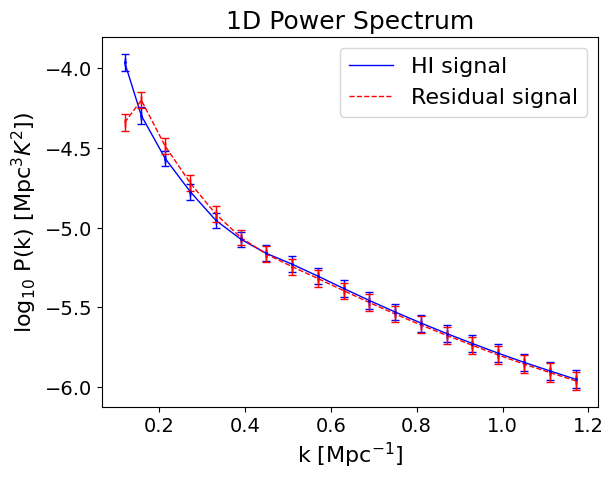

In [271]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_[0, 0.1]_None.pdf


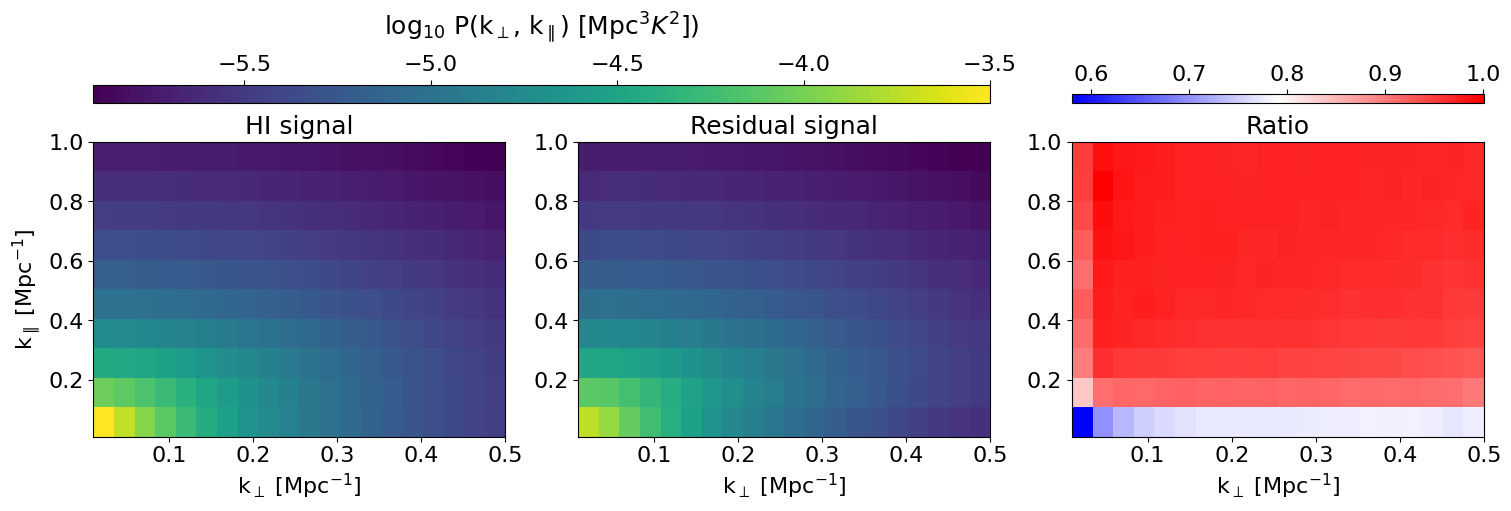

In [272]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.04)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2, labelpad = 15)
cbar.ax.set_position([pos0.x0, pos0.y0 + 5, pos0.width, pos0.height])
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.04)
save_project_plot(plt.gcf(), week_number = 5, filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [285]:
seed = 42
k_perppara_min = [0.025, 0.06]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [286]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:18<00:00,  1.27it/s]



Total time: 1.60 minutes (95.96 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0.025, 0.06]_None.pdf


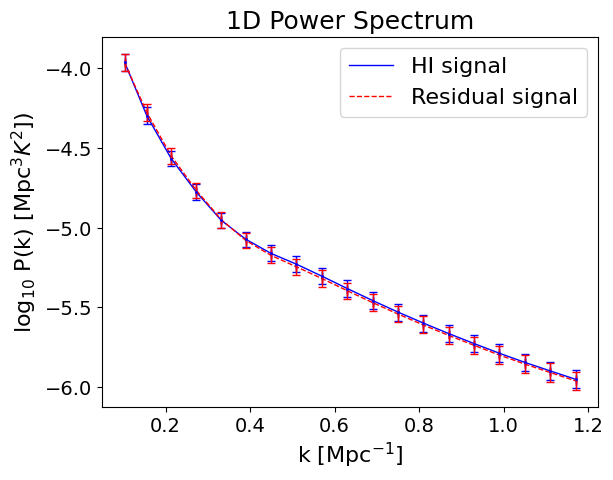

In [287]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_[0.025, 0.06]_None.pdf


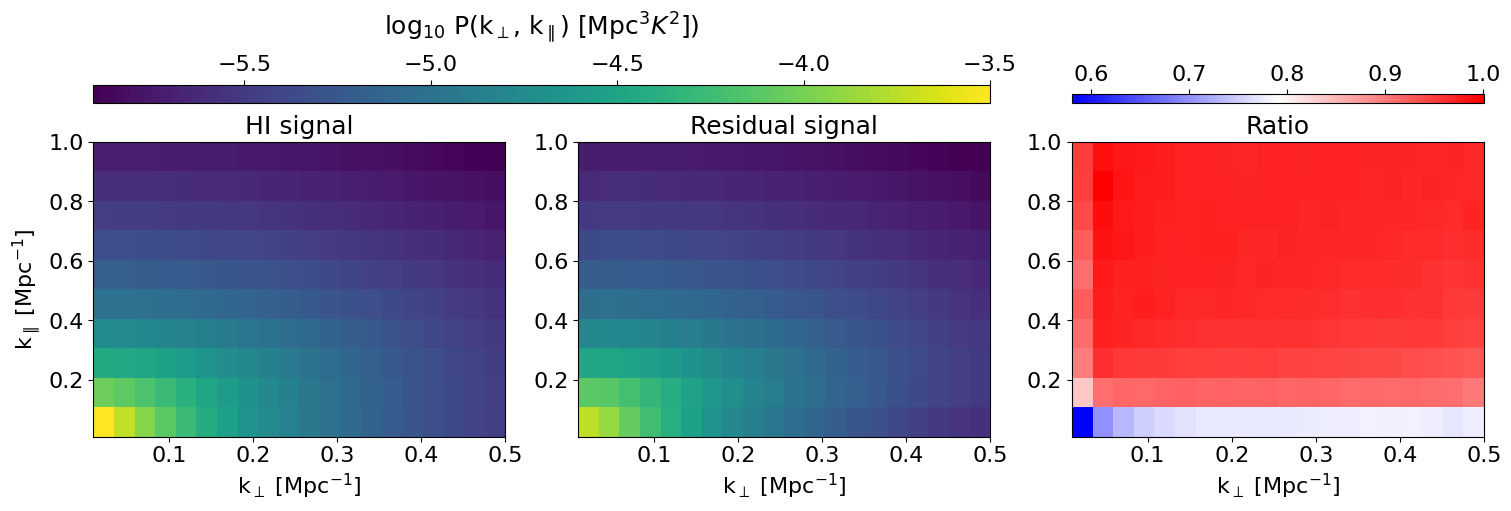

In [288]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.04)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2, labelpad = 15)
cbar.ax.set_position([pos0.x0, pos0.y0 + 5, pos0.width, pos0.height])
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.04)
save_project_plot(plt.gcf(), week_number = 5, filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [289]:
seed = 42
k_perppara_min = [0.02, 0.06]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [290]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:35<00:00,  1.05it/s]



Total time: 1.87 minutes (112.25 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0.02, 0.06]_None.pdf


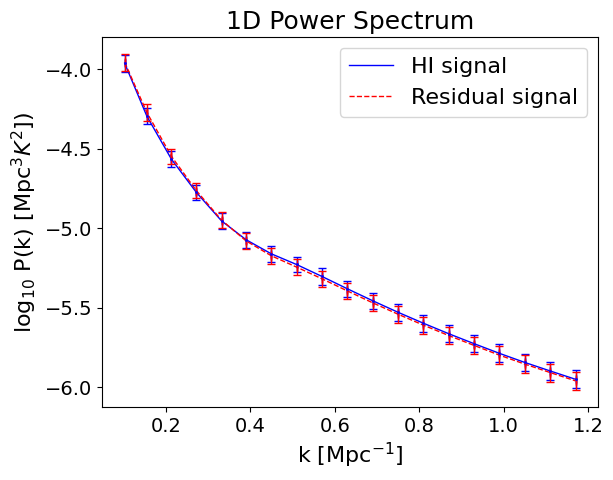

In [291]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_[0.02, 0.06]_None.pdf


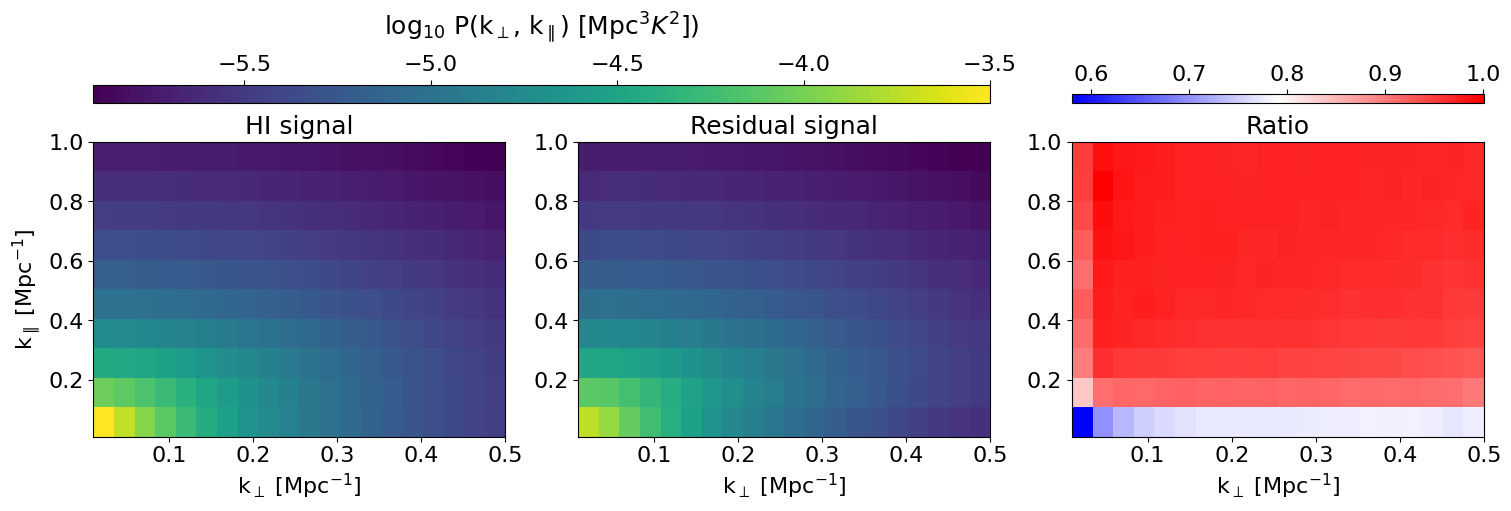

In [292]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.04)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2, labelpad = 15)
cbar.ax.set_position([pos0.x0, pos0.y0 + 5, pos0.width, pos0.height])
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.04)
save_project_plot(plt.gcf(), week_number = 5, filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [293]:
seed = 42
k_perppara_min = [0.015, 0.06]
k_perppara_max = None

k_1d, power_1d_map, power_1d_res, power_cy_map, power_cy_res = generate_power_spectrum_data(seed, fg_map, k_perppara_min, k_perppara_max, 
                                                                                            map_type = "hi")

k_1d_list, power_1d_hi_list, power_1d_res_list = [k_1d], [power_1d_map], [power_1d_res]
power_cy_hi_list, power_cy_res_list = [power_cy_map], [power_cy_res]

In [294]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:32<00:00,  1.08it/s]



Total time: 1.81 minutes (108.71 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0.015, 0.06]_None.pdf


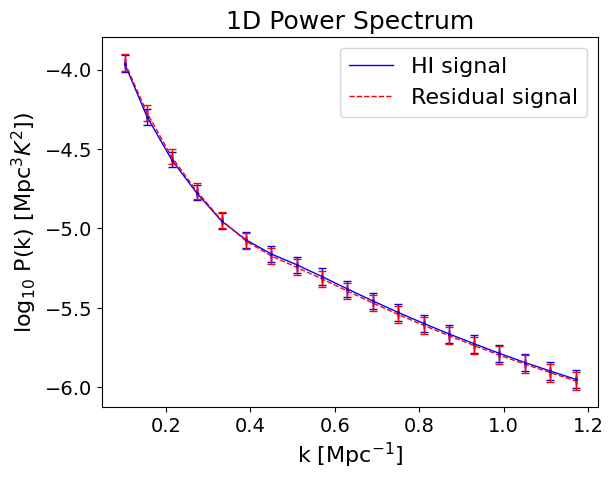

In [295]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")

# show plot
plt.show()



Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_[0.015, 0.06]_None.pdf


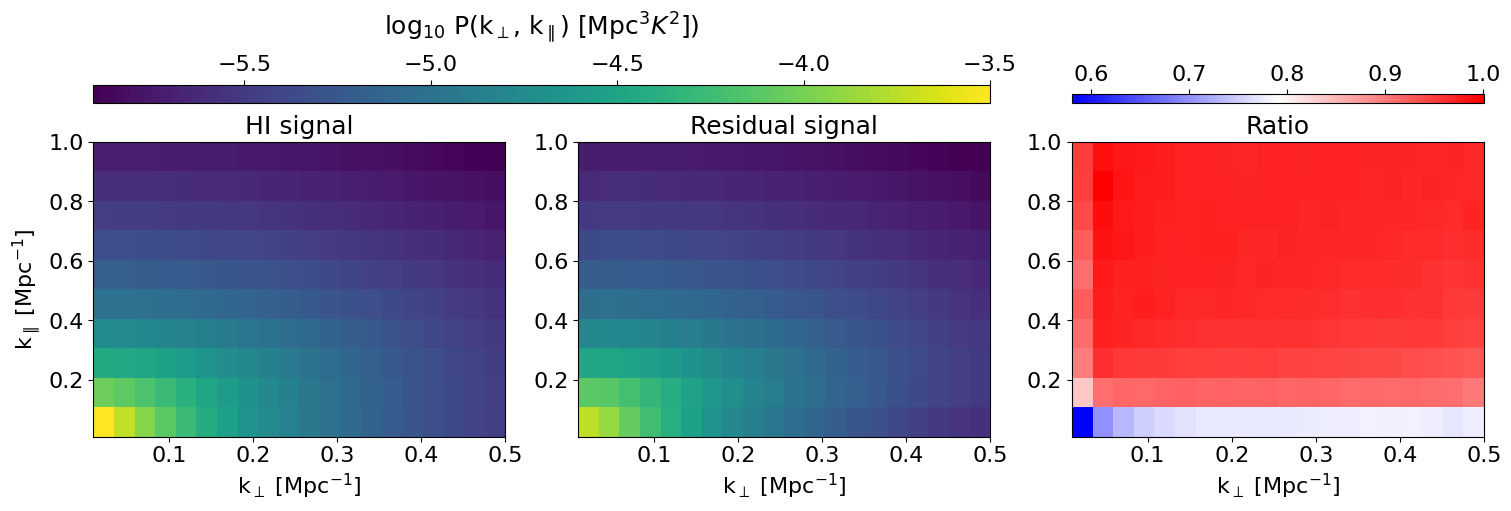

In [296]:
power_cy_hi_mean = np.mean(power_cy_hi_list, axis = 0)
power_cy_res_mean = np.mean(power_cy_res_list, axis = 0)

fs = 16
vmin = np.log10([power_cy_hi_mean.min(),power_cy_res_mean.min()]).min()
vmax = np.log10([power_cy_hi_mean.max(),power_cy_res_mean.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5), layout = "constrained")
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi_mean.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[0].set_title('HI signal', fontsize = fs+2)
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res_mean.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[1].set_title('Residual signal', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.04)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)', fontsize = fs+2, labelpad = 15)
cbar.ax.set_position([pos0.x0, pos0.y0 + 5, pos0.width, pos0.height])
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res_mean.T/power_cy_hi_mean.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]', fontsize = fs)
#axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]', fontsize = fs)
axes[2].set_title('Ratio', fontsize = fs+2)
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.04)
save_project_plot(plt.gcf(), week_number = 5, filename = f"cylindrical_power_spectrum_{k_perppara_min}_{k_perppara_max}.pdf")
plt.show()

In [297]:
seed = 42
k_perppara_min = [0.015, 0.06]
k_perppara_max = None

In [298]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:11<00:00,  1.39it/s]



Total time: 1.47 minutes (88.24 seconds)


Processing seeds: 100%|███████████████████████| 100/100 [01:10<00:00,  1.41it/s]



Total time: 1.46 minutes (87.58 seconds)


In [310]:
k_1d_list, power_1d_hi_list, power_1d_res_list, power_cy_hi_list, power_cy_res_list = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = None, 
                                                                                                                                    k_perppara_max = None, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:11<00:00,  1.40it/s]



Total time: 1.47 minutes (88.27 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0.015, 0.06]_None_both.pdf


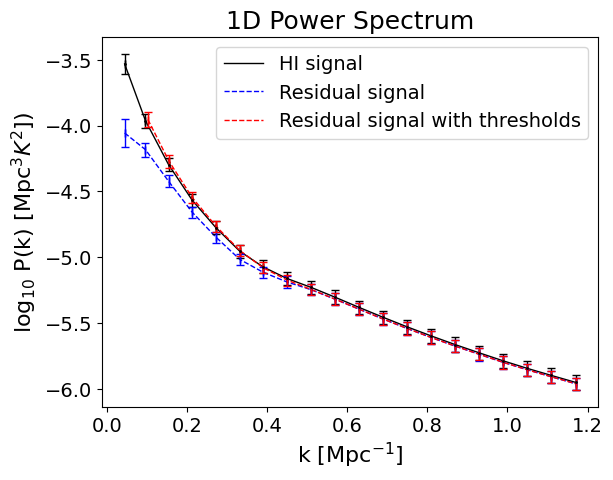

In [317]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()



In [318]:
seed = 42
k_perppara_min = [0, 0.04]
k_perppara_max = None

In [319]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:15<00:00,  1.33it/s]



Total time: 1.47 minutes (88.10 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.04]_None_both.pdf


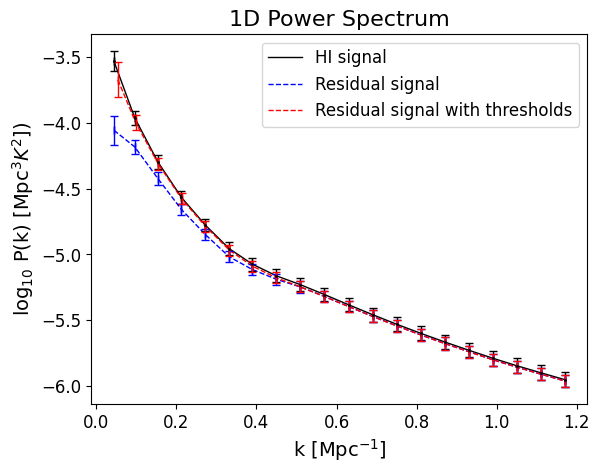

In [340]:
fs = 14

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()



In [321]:
seed = 42
k_perppara_min = [0, 0.05]
k_perppara_max = None

In [322]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:11<00:00,  1.41it/s]



Total time: 1.46 minutes (87.56 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.05]_None_both.pdf


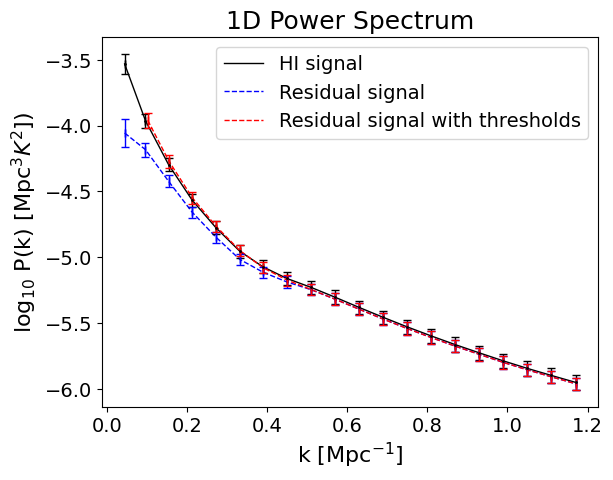

In [323]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()



In [335]:
seed = 42
k_perppara_min = [0, 0.04]
k_perppara_max = None

In [336]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:43<00:00,  1.03s/it]



Total time: 2.03 minutes (121.82 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.04]_None_both.pdf


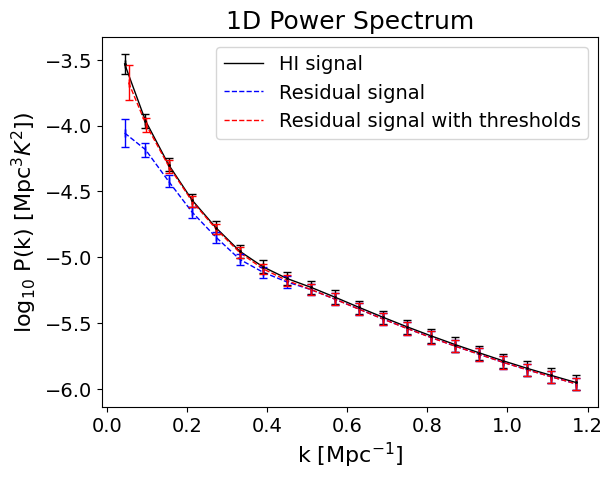

In [337]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()



In [324]:
seed = 42
k_perppara_min = [0, 0.03]
k_perppara_max = None

In [325]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:17<00:00,  1.29it/s]



Total time: 1.64 minutes (98.12 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.03]_None_both.pdf


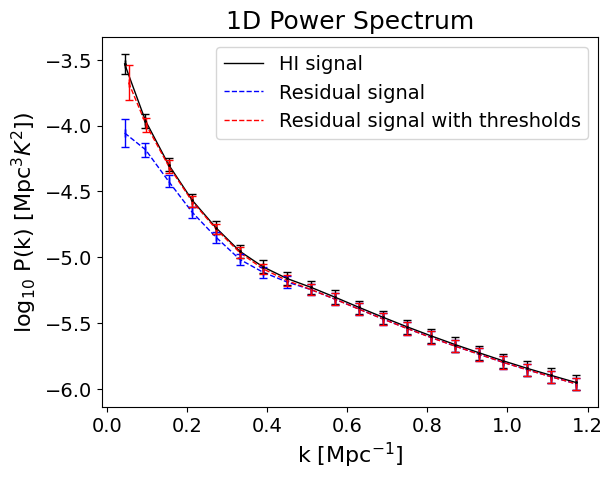

In [326]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()



In [328]:
seed = 42
k_perppara_min = [0, 0.02]
k_perppara_max = None

In [329]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:12<00:00,  1.38it/s]



Total time: 1.51 minutes (90.74 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.02]_None_both.pdf


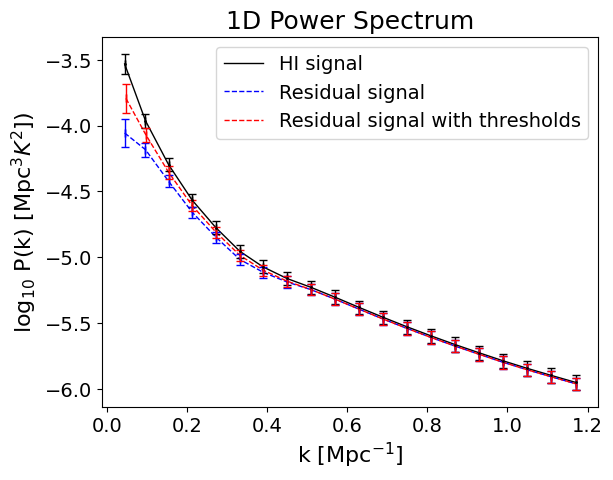

In [330]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()



In [331]:
seed = 42
k_perppara_min = [0, 0.01]
k_perppara_max = None

In [332]:
k_1d_list_cleaned, power_1d_hi_list_cleaned, power_1d_res_list_cleaned, power_cy_hi_list_cleaned, power_cy_res_list_cleaned = generate_power_spectrum_data_100_realisations(fg_map, k_perppara_min = k_perppara_min, 
                                                                                                                                    k_perppara_max = k_perppara_max, map_type = "hi")




Processing seeds: 100%|███████████████████████| 100/100 [01:21<00:00,  1.23it/s]



Total time: 1.69 minutes (101.54 seconds)


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week9/1d_log_power_spectrum_[0, 0.01]_None_both.pdf


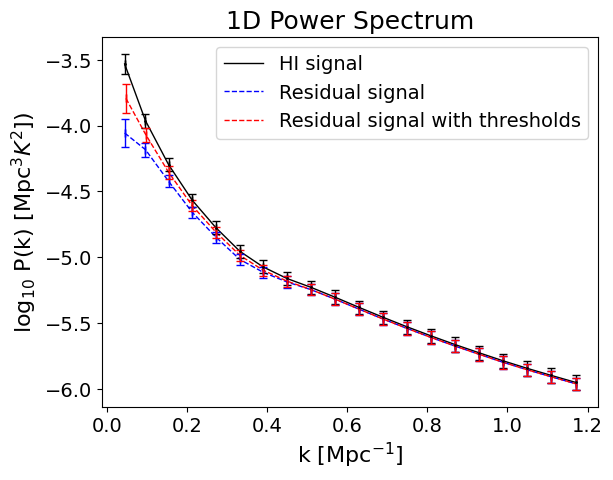

In [333]:
fs = 16

# calculate log values
log_power_1d_hi_list = np.log10(power_1d_hi_list)
log_power_1d_res_list = np.log10(power_1d_res_list)
log_power_1d_res_list_cleaned = np.log10(power_1d_res_list_cleaned)

# calculate means
k_1d_mean = np.mean(k_1d_list, axis = 0)
log_power_1d_hi_mean = np.mean(log_power_1d_hi_list, axis = 0)
log_power_1d_res_mean = np.mean(log_power_1d_res_list, axis = 0)
k_1d_mean_cleaned = np.mean(k_1d_list_cleaned, axis = 0)
log_power_1d_res_mean_cleaned = np.mean(log_power_1d_res_list_cleaned, axis = 0)

# calculate standard deviations
k_1d_std = np.std(k_1d_list, axis = 0)
log_power_1d_hi_std = np.abs(np.std(log_power_1d_hi_list, axis = 0))
log_power_1d_res_std = np.abs(np.std(log_power_1d_res_list, axis = 0))

k_1d_std_cleaned = np.std(k_1d_list_cleaned, axis = 0)
log_power_1d_res_std_cleaned = np.abs(np.std(log_power_1d_res_list_cleaned, axis = 0))

# plot the log 1D power spectrum
plt.plot(k_1d_mean, log_power_1d_hi_mean, label='HI signal', color = 'black', linewidth = 1)
plt.plot(k_1d_mean, log_power_1d_res_mean, label='Residual signal',ls='--', color = 'blue', linewidth = 1)
plt.plot(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, label='Residual signal with thresholds',ls='--', color = 'red', linewidth = 1)

plt.errorbar(k_1d_mean, log_power_1d_hi_mean, yerr = log_power_1d_hi_std, xerr = k_1d_std, fmt = 'o', capsize = 3, color = 'black', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean, log_power_1d_res_mean, yerr = log_power_1d_res_std, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'blue', markersize = 1, linewidth = 1)
plt.errorbar(k_1d_mean_cleaned, log_power_1d_res_mean_cleaned, yerr = log_power_1d_res_std_cleaned, xerr = k_1d_std, fmt = 'None', capsize = 3, color = 'red', markersize = 1, linewidth = 1)

# add title and labels
plt.xlabel('k [Mpc$^{-1}$]', fontsize=fs)
plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)', fontsize=fs)
plt.title('1D Power Spectrum', fontsize=fs+2)
plt.tick_params(labelsize=fs-2)
plt.legend(fontsize=fs-2)

save_project_plot(plt.gcf(), week_number = 9, 
                  filename = f"1d_log_power_spectrum_{k_perppara_min}_{k_perppara_max}_both.pdf")

# show plot
plt.show()

